In [1]:
"""
Phase Retrieval via Implicit Prior in a Denoiser
===================================================

Master's project implementing the method from:
"Solving Linear Inverse Problems Using the Prior Implicit in a Denoiser"
(Kadkhodaie & Simoncelli, 2020)

Adapted for the non-linear Phase Retrieval problem in the real domain.
"""

'\nPhase Retrieval via Implicit Prior in a Denoiser\n===================================================\n\nMaster\'s project implementing the method from:\n"Solving Linear Inverse Problems Using the Prior Implicit in a Denoiser"\n(Kadkhodaie & Simoncelli, 2020)\n\nAdapted for the non-linear Phase Retrieval problem in the real domain.\n'

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import time
import tqdm
from pathlib import Path
import json
from typing import Tuple, Dict, List
import logging
import torch.nn.functional as F

In [48]:
# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Configuration for the Phase Retrieval experiment."""
    
    # Dataset
    dataset_name: str = "FashionMNIST"
    image_size: int = 28
    n_pixels: int = 28 * 28  # N = 784
    
    # Measurement matrix
    oversample_ratio: float = 3.0  # M/N ratio
    measurement_dim: int = int(n_pixels * oversample_ratio)  # M
    seed_measurement: int = 42
    
    # DnCNN Denoiser Architecture
    #denoiser_num_layers: int = 17  # Number of conv layers (original DnCNN uses 17)
    #denoiser_num_features: int = 64  # Base feature channels
    #denoiser_use_batch_norm: bool = False  # No batch norm for bias-free version

    # BF-CNN Denoiser Architecture
    denoiser_num_layers: int = 12 #17  # Number of conv layers
    denoiser_num_channels: int = 32 #64  # Base feature channels
    
    # Denoiser Training
    batch_size_train: int = 128
    num_epochs: int = 20 #50
    learning_rate: float = 1e-3
    sigma_max: float = 0.4  # Maximum noise level for training (adjusted for image values in [0,1])
    seed_denoiser: int = 123
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Phase Retrieval Algorithm
    sigma_0: float = 3.0         # Initial noise level
    sigma_L: float = 0.01        # Final noise level
    h0: float = 0.01             # Initial step size parameter
    beta: float = 0.01           # Noise injection parameter [0, 1]
    max_iterations: int = 500    # Maximum iterations
    
    # Visualization
    save_dir: Path = Path("./outputs")
    save_intermediates_freq: int = 10  # Save every N iterations

    # Phase Retrieval Algorithm
    alpha_max = 1.0  # Projection dure au début
    alpha_min = 0.05 # Projection plus douce à la fin
    sigma_threshold = 0.1 # Seuil de σ_t pour passer de alpha_max à alpha_min

In [4]:
class BF_CNN(nn.Module): ## Modèle cité par les auteurs 

    def __init__(self, depth=20, n_channels=64, image_channels=1):
        super(BF_CNN, self).__init__()
        kernel_size = 3
        padding = 1
        layers = []
        
        
        layers.append(nn.Conv2d(image_channels, n_channels, kernel_size, padding=padding, bias=False))
        layers.append(nn.ReLU(inplace=True))
        
        for _ in range(depth - 2):
            layers.append(nn.Conv2d(n_channels, n_channels, kernel_size, padding=padding, bias=False))
            
            bn = nn.BatchNorm2d(n_channels, affine=True) # enlever les biais 
            bn.register_parameter('bias', None) 
            layers.append(bn)
            
            layers.append(nn.ReLU(inplace=True))
            
        layers.append(nn.Conv2d(n_channels, image_channels, kernel_size, padding=padding, bias=False))
        
        self.dncnn = nn.Sequential(*layers)

    def forward(self, x):
        noise = self.dncnn(x)
        return x - noise


In [ ]:
# ============================================================================
# MEASUREMENT MATRIX AND PHASE RETRIEVAL PROJECTOR
# ============================================================================

class PhaseRetrievalTask:
    """
    Encapsulates the phase retrieval forward and inverse operators.
    
    Real-domain formulation:
        - Observations: b = |A x*|  (magnitude of Ax*)
        - Constraint set: S_PR = {x : |Ax| matches phases of current estimate}
    """
    
    def __init__(
        self, 
        measurement_dim: int,
        image_dim: int,
        seed: int = 42,
        device: str = "cpu"
    ):
        """
        Args:
            measurement_dim: M (number of measurements)
            image_dim: N (image dimension, e.g., 784 for 28x28)
            seed: Random seed for reproducibility
            device: "cpu" or "cuda"
        """
        self.M_shape = (measurement_dim, image_dim)
        self.N = image_dim
        self.M_size = measurement_dim
        self.device = device
        
        # Generate random measurement matrix A ~ N(0, 1/N)
        rng = np.random.RandomState(seed)
        A = rng.randn(measurement_dim, image_dim) / np.sqrt(image_dim)
        self.A = torch.from_numpy(A).float().to(device)
        
        # Compute pseudo-inverse A^+ once and store
        self.A_pinv = torch.linalg.pinv(self.A)
        
        print(f"Measurement matrix A: {self.A.shape}")
        print(f"Pseudo-inverse A^+: {self.A_pinv.shape}")
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward operator: A @ x (linear measurement)
        
        Args:
            x: Image [N] or [B, N]
        
        Returns:
            Measurements [M] or [B, M]
        """
        if x.dim() == 1:
            return self.A @ x
        else:  # Batch
            return x @ self.A.T
    
    def get_magnitudes(self, x: torch.Tensor) -> torch.Tensor:
        """
        Get observation magnitudes b = |A x|
        
        Args:
            x: Image [N] or [B, N]
        
        Returns:
            Magnitudes [M] or [B, M]
        """
        return torch.abs(self.forward(x))
    
    def get_signs(self, x: torch.Tensor) -> torch.Tensor:
        """
        Get signs of measurements sign(A x)
        
        Args:
            x: Image [N] or [B, N]
        
        Returns:
            Signs {-1, +1} [M] or [B, M]
        """
        return torch.sign(self.forward(x))
    
    def project_to_constraint_set(
        self, 
        y: torch.Tensor, 
        b: torch.Tensor
    ) -> torch.Tensor:
        """
        Project y onto the constraint set S_PR.
        
        Implementation of:
            P_S_PR(z) = A^+ (b ⊙ sign(A z))
        
        where b are the measured magnitudes and ⊙ is element-wise multiplication.
        
        Args:
            y: Current estimate [N] or [B, N]
            b: Target magnitudes [M] or [B, M]
        
        Returns:
            Projected image [N] or [B, N]
        """
        # Get signs of current estimate's measurements
        signs = self.get_signs(y)
        
        # Element-wise product of magnitudes and signs
        constrained_meas = b * signs
        
        # Project back to image space via pseudo-inverse
        if y.dim() == 1:
            return self.A_pinv @ constrained_meas
        else:  # Batch
            return constrained_meas @ self.A_pinv.T
    
    def project_to_constraint_set_relaxed(
        self, 
        y_prime: torch.Tensor, 
        b: torch.Tensor,
        alpha_t: float
    ) -> torch.Tensor:
        """
        Interpolation vers la projection dure.

        P_S_PR_relaxed(z) = (1 - α_t) * z + α_t * P_S_PR(z)
        where P_S_PR(z) = A^+ (b ⊙ sign(A z))

        Args:
            y_prime: Current estimate [N] or [B, N]
            b: Target magnitudes [M] or [B, M]
            alpha_t: Relaxation parameter [0, 1]
        
        Returns:
            Relaxed projected image [N] or [B, N]
        """
        # 1. Calculer la projection dure (exacte) comme avant
        signs = self.get_signs(y_prime)
        constrained_meas = b * signs
        
        if y_prime.dim() == 1:
            y_hard = self.A_pinv @ constrained_meas
        else:
            y_hard = constrained_meas @ self.A_pinv.T
            
        # 2. Interpoler : si alpha_t = 1, c'est une projection dure. Si = 0, on ne fait rien.
        y_proj = (1.0 - alpha_t) * y_prime + alpha_t * y_hard
        
        return y_proj

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import tqdm
from typing import Dict, List

# ============================================================================
# DENOISER TRAINING
# ============================================================================

def train_blind_denoiser(
    model: nn.Module,
    config: Config,
    train_loader: DataLoader,
    val_loader: DataLoader = None,
) -> Dict[str, List[float]]:
    """
    Train the DnCNN-style blind denoiser on Gaussian noise corruption.
    
    Loss: MSE between denoiser output D(y) and ground truth x.
    
    The denoiser learns to estimate E[x | y] for Gaussian noise of any level σ.
    
    Args:
        model: DnCNNDenoiser instance
        config: Configuration object
        train_loader: Training data loader
        val_loader: Validation data loader (optional)
    
    Returns:
        Dictionary with training history
    """
    device = config.device
    model = model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate) #, weight_decay=1e-5)
    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'epoch': [],
        'learning_rate': []
    }

    best_val_loss = float('inf')
    patience_counter = 0
    
    print("Starting denoiser training...")
    print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    for epoch in range(config.num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        n_batches = 0
        
        for x_clean, _ in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.num_epochs}"):
            x_clean = x_clean.to(device)
            
            # Correction: Sample a different noise level for EACH image in the batch
            # Shape: [batch_size, 1, 1, 1] for proper broadcasting
            batch_size = x_clean.shape[0]
            sigma = torch.rand(batch_size, 1, 1, 1, device=device) * config.sigma_max
            
            # Add Gaussian noise: y = x + ε
            noise = torch.randn_like(x_clean) * sigma
            y_noisy = x_clean + noise
            
            # Forward pass: denoiser predicts clean image
            x_hat = model(y_noisy)
            
            # MSE loss
            loss = criterion(x_hat, x_clean)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            n_batches += 1
        
        train_loss /= n_batches
        history['train_loss'].append(train_loss)
        
        # Validation phase
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            n_val_batches = 0
            
            with torch.no_grad():
                for x_clean, _ in tqdm.tqdm(val_loader, desc=f"Validation Epoch {epoch+1}/{config.num_epochs}"):
                    x_clean = x_clean.to(device)
                    
                    # Same correction for validation
                    batch_size = x_clean.shape[0]
                    sigma = torch.rand(batch_size, 1, 1, 1, device=device) * config.sigma_max
                    
                    noise = torch.randn_like(x_clean) * sigma
                    y_noisy = x_clean + noise
                    x_hat = model(y_noisy)
                    val_loss += criterion(x_hat, x_clean).item()
                    n_val_batches += 1
            
            val_loss /= n_val_batches
            history['val_loss'].append(val_loss)
            history['epoch'].append(epoch)
            history['learning_rate'].append(optimizer.param_groups[0]['lr'])
            
            # Learning rate scheduling
            scheduler.step(val_loss)
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), 'best_denoiser.pt')
            else:
                patience_counter += 1
                if patience_counter >= 5:
                    print(f"Early stopping at epoch {epoch}")
                    break
            
            print(
                f"Epoch {epoch+1:3d}/{config.num_epochs} - "
                f"Train Loss: {train_loss:.8f} - Val Loss: {val_loss:.8f} -"
                f"LR: {optimizer.param_groups[0]['lr']:.2e}"
            )
            
        else:
            print(f"Epoch {epoch+1:3d}/{config.num_epochs} - Train Loss: {train_loss:.8f}")
    
    print("Denoiser training complete!")

    # Load the best model before returning
    try:
        model.load_state_dict(torch.load('best_denoiser.pt'))
    except FileNotFoundError:
        print("Warning: 'best_denoiser.pt' not found, using last epoch's weights.")

    return history

In [49]:
# ============================================================================
# PHASE RETRIEVAL ALGORITHM (CORE CONTRIBUTION)
# ============================================================================

def phase_retrieval_algorithm(
    denoiser: nn.Module,
    task: PhaseRetrievalTask,
    measurements: torch.Tensor,
    config: Config,
    test_ground_truth: torch.Tensor = None,
) -> Tuple[torch.Tensor, Dict]:
    """
    Solve phase retrieval using implicit prior from denoiser.
    
    Algorithm:
        1. Initialize y_0 satisfying constraints
        2. For each iteration:
            a. Compute denoiser residual: d_raw = D(y_{t-1}) - y_{t-1}
            b. Estimate noise variance: σ_t = ||d_raw|| / √N
            c. Gradient ascent step: y' = y_{t-1} + h_t * d_raw
            d. Project onto constraint set: x_proj = P_S_PR(y')
            e. Add Langevin noise: y_t = x_proj + γ_t * z_t
    
    Args:
        denoiser: Trained blind denoiser D(y)
        task: PhaseRetrievalTask instance with matrix A and pseudo-inverse
        measurements: Target magnitudes b = |A x*| [M]
        config: Configuration object
        test_ground_truth: Ground truth for MSE evaluation (optional) [N]
    
    Returns:
        Tuple of:
            - Final reconstructed image [N]
            - Dictionary with metrics and intermediates
    """
    device = config.device
    denoiser = denoiser.to(device).eval()
    
    N = task.N
    M = task.M_size
    
    # Reshape measurements and ground truth if needed
    if measurements.dim() > 1:
        measurements = measurements.squeeze()
    
    measurements = measurements.to(device)
    
    results = {
        'iterations': 0,
        'sigma_trajectory': [],
        'time_per_iter': [],
        'mse_trajectory': [],
        'intermediates': [],
    }
    
    # ========== INITIALIZATION ==========
    # y_0 = P_S_PR(z_0) where z_0 ~ N(0, σ_0^2 I)
    # This ensures starting point respects measurements
    
    print("Initializing phase retrieval algorithm...")
    
    z_raw = torch.randn(N, device=device) * config.sigma_0
    y = task.project_to_constraint_set(z_raw, measurements)
    
    # Reshape to [1, 1, H, W] for denoiser
    y_im = y.view(1, 1, config.image_size, config.image_size)
    
    if test_ground_truth is not None:
        test_ground_truth = test_ground_truth.to(device)
        mse = torch.norm(y - test_ground_truth).item() ** 2 / N
        results['mse_trajectory'].append(mse)
        print(f"Initial MSE: {mse:.6f}")
    
    # ========== MAIN LOOP ==========
    t = 1
    time_start = time.time()
    sigma_t = config.sigma_0
    
    while sigma_t >= config.sigma_L and t <= config.max_iterations:
        # ===== Step 1: Compute denoiser residual (gradient direction) =====
        with torch.no_grad():
            y_hat = denoiser(y_im)  # D(y)
        
        y_hat_flat = y_hat.view(-1)  # Flatten to [N]
        d_raw = y_hat_flat - y  # Residual = gradient direction
        
        # ===== Step 2: Estimate noise variance from residual =====
        # σ_t = ||d_raw|| / √N
        # estimate variance before projection
        sigma_t = torch.norm(d_raw).item() / np.sqrt(N)
        results['sigma_trajectory'].append(sigma_t)
        
        # Stop if noise is small enough
        if sigma_t < config.sigma_L:
            print(f"Converged at iteration {t}: σ_t = {sigma_t:.6f} < σ_L = {config.sigma_L}")
            break
        
        # ===== Step 3: Adaptive step size =====
        # h_t = h_0 * t / (1 + h_0 * (t - 1))
        h_t = config.h0 * t / (1 + config.h0 * (t - 1))
        
        # ===== Step 4: Gradient ascent on manifold =====
        # y' = y_{t-1} + h_t * d_raw
        y_prime = y + h_t * d_raw
        
        # ===== Step 5: Project onto constraint set (non-linear operator) =====
        # x_proj = P_S_PR(y') = A^+ (b ⊙ sign(A y'))
        #y_proj = task.project_to_constraint_set(y_prime, measurements)

        # Alternative: use relaxed projection with interpolation
        if sigma_t >= config.sigma_threshold:
            alpha_t = config.alpha_max
        else:
            # Interpolation linéaire entre alpha_min et alpha_max
            ratio = (sigma_t - config.sigma_L) / (config.sigma_threshold - config.sigma_L)
            ratio = max(0.0, min(1.0, ratio))
            print(f"Iteration {t}: σ_t={sigma_t:.6f} using relaxed projection with ratio={ratio:.3f} and alpha_t={alpha_t:.3f}")
            alpha_t = config.alpha_min + (config.alpha_max - config.alpha_min) * ratio
        
        y_proj = task.project_to_constraint_set_relaxed(y_prime, measurements, alpha_t)
        
        # ===== Step 6: Compute Langevin noise amplitude =====
        # γ_t^2 = [(1 - β*h_t)^2 - (1 - h_t)^2] * σ_t^2
        gamma_squared = (
            (1 - config.beta * h_t) ** 2 - (1 - h_t) ** 2
        ) * (sigma_t ** 2)
        gamma_t = np.sqrt(max(gamma_squared, 0.0))  # Ensure non-negative
        
        # ===== Step 7: Inject noise =====
        # y_t = x_proj + γ_t * z_t
        z_t = torch.randn(N, device=device)
        y = y_proj + gamma_t * z_t
        
        # Reshape for next denoiser call
        y_im = y.view(1, 1, config.image_size, config.image_size)
        
        # ===== Tracking and logging =====
        if test_ground_truth is not None:
            mse = torch.norm(y - test_ground_truth).item() ** 2 / N
            results['mse_trajectory'].append(mse)
        
        if t % config.save_intermediates_freq == 0:
            results['intermediates'].append(y.detach().cpu().clone())
            elapsed = time.time() - time_start
            results['time_per_iter'].append(elapsed / t)
            
            log_str = f"Iter {t:3d} | σ={sigma_t:.6f} | h={h_t:.6f} | γ={gamma_t:.6f}"
            if test_ground_truth is not None:
                log_str += f" | MSE={mse:.6f}"
            print(log_str)
        
        t += 1
    
    results['iterations'] = t - 1
    results['total_time'] = time.time() - time_start
    
    print(f"Phase retrieval completed in {results['iterations']} iterations ({results['total_time']:.2f}s)")
    
    return y.detach().cpu(), results

In [50]:
# ============================================================================
# EVALUATION METRICS
# ============================================================================

def evaluate_reconstruction(
    x_reconstructed: torch.Tensor,
    x_ground_truth: torch.Tensor,
    A: torch.Tensor,
    b_observed: torch.Tensor,
) -> Dict[str, float]:
    """
    Evaluate reconstruction quality.
    
    Args:
        x_reconstructed: Reconstructed image [N]
        x_ground_truth: Ground truth image [N]
        A: Measurement matrix [M, N]
        b_observed: Observed magnitudes [M]
    
    Returns:
        Dictionary of metrics
    """
    # MSE in image space
    mse_img = (torch.norm(x_reconstructed - x_ground_truth) ** 2).item() / x_ground_truth.numel()
    
    # Measurement error
    b_recon = torch.abs(A @ x_reconstructed)
    measurement_error = (torch.norm(b_recon - b_observed) ** 2).item() / b_observed.numel()
    
    # PSNR (for reference, though not the main metric for stochastic method)
    max_val = x_ground_truth.max().item()
    psnr = 10 * np.log10(max_val ** 2 / mse_img) if mse_img > 0 else float('inf')
    
    return {
        'mse_image': mse_img,
        'measurement_error': measurement_error,
        'psnr': psnr,
    }

In [58]:
# ============================================================================
# VISUALIZATION
# ============================================================================

def visualize_results(
    x_orig: torch.Tensor,
    x_recon: torch.Tensor,
    measurement: torch.Tensor,
    trajectory: List[torch.Tensor],
    metrics: Dict,
    save_path: Path,
    image_size: int = 28,
):
    """
    Visualize reconstruction results and convergence trajectory.
    
    Args:
        x_orig: Original image [N]
        x_recon: Reconstructed image [N]
        measurement: Observed magnitudes [M]
        trajectory: List of intermediate reconstructions
        metrics: Evaluation metrics
        save_path: Path to save figures
        image_size: Image height/width
    """
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    
    # Original
    axes[0, 0].imshow(x_orig.view(image_size, image_size), cmap='gray')
    axes[0, 0].set_title('Ground Truth')
    axes[0, 0].axis('off')

    # Measurement plot : plot the observed magnitudes as an image
    b_img = measurement.view(int(np.sqrt(measurement.numel())), -1).cpu()
    axes[0, 1].imshow(b_img, cmap='viridis')
    axes[0, 1].set_title('Observed Magnitudes')
    axes[0, 1].axis('off')
    
    # Reconstruction
    axes[0, 2].imshow(x_recon.view(image_size, image_size), cmap='gray')
    axes[0, 2].set_title('Reconstructed')
    axes[0, 2].axis('off')
    
    # Difference
    diff = (x_recon - x_orig).abs()
    axes[1, 2].imshow(diff.view(image_size, image_size), cmap='hot')
    axes[1, 2].set_title('Absolute Error')
    axes[1, 2].axis('off')
    
    # Trajectories (2 samples)
    n_traj = min(2, len(trajectory))
    for i in range(n_traj):
        idx = (i + 1) * len(trajectory) // (n_traj + 1)
        ax = axes[1, i] if n_traj <= 3 else axes[1, i // 2]
        im = trajectory[idx].view(image_size, image_size)
        ax.imshow(im, cmap='gray')
        ax.set_title(f'Iter {idx * 10}')
        ax.axis('off')    
    
    plt.suptitle(
        f"Phase Retrieval | MSE={metrics['mse_image']:.6f} | "
        f"Meas.Err={metrics['measurement_error']:.6f} | "
        f"PSNR={metrics['psnr']:.2f}dB",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig(save_path / 'reconstruction.png', dpi=150, bbox_inches='tight')
    print(f"Saved reconstruction figure to {save_path / 'reconstruction.png'}")
    
    # Convergence plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(metrics['sigma_trajectory'], linewidth=2, label='σ_t')
    ax.axhline(y=0.01, color='r', linestyle='--', label='σ_L')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Noise Level')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_title('Convergence: Noise Level Over Iterations')
    plt.tight_layout()
    plt.savefig(save_path / 'convergence.png', dpi=150, bbox_inches='tight')
    print(f"Saved convergence plot to {save_path / 'convergence.png'}")

In [51]:
# Create output directory
config = Config()
config.save_dir.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("PHASE RETRIEVAL VIA IMPLICIT DENOISER PRIOR")
print("=" * 70)
print(f"Device: {config.device}")
print(f"Dataset: {config.dataset_name}")
print(f"Image Size: {config.image_size}x{config.image_size}")
print(f"Measurement Dim: M={config.measurement_dim}, Image Dim: N={config.n_pixels}")
print(f"Oversample Ratio: M/N = {config.oversample_ratio}")

PHASE RETRIEVAL VIA IMPLICIT DENOISER PRIOR
Device: cuda
Dataset: FashionMNIST
Image Size: 28x28
Measurement Dim: M=2352, Image Dim: N=784
Oversample Ratio: M/N = 3.0


In [37]:
# ========== STEP 1: LOAD FASHIONMNIST DATA ==========
print("\n--- Loading FashionMNIST Dataset ---")

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
val_dataset = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(
    train_dataset, batch_size=config.batch_size_train, shuffle=True
)
val_loader = DataLoader(
    val_dataset, batch_size=config.batch_size_train, shuffle=False
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")


--- Loading FashionMNIST Dataset ---
Training samples: 60000
Validation samples: 10000


In [12]:
# ========== STEP 2: TRAIN BLIND DENOISER ==========
print("\n--- Training Blind Denoiser ---")

torch.manual_seed(config.seed_denoiser)
"""
denoiser = DnCNNDenoiser(
    num_layers=config.denoiser_num_layers,
    num_features=config.denoiser_num_features,
    use_batch_norm=config.denoiser_use_batch_norm,
)
"""
denoiser = BF_CNN(
    depth=config.denoiser_num_layers,
    n_channels=config.denoiser_num_channels,
    image_channels=1
)


print(f"DnCNN Architecture:")
print(f"  - Number of layers: {config.denoiser_num_layers}")
print(f"  - Number of channels: {config.denoiser_num_channels}")
#print(f"  - Feature channels: {config.denoiser_num_features}")
#print(f"  - Batch normalization: {config.denoiser_use_batch_norm}")
print(f"  - Total parameters: {sum(p.numel() for p in denoiser.parameters()):,}")

denoiser_history = train_blind_denoiser(
    denoiser, config, train_loader, val_loader
)

# Save denoiser
torch.save(
    denoiser.state_dict(),
    config.save_dir / 'bfcnn_denoiser.pt'
)
print(f"Saved denoiser to {config.save_dir / 'bfcnn_denoiser.pt'}")

# Plot training history
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(denoiser_history['train_loss'], label='Training Loss', linewidth=2)
if denoiser_history['val_loss']:
    ax.plot(denoiser_history['epoch'], denoiser_history['val_loss'], 
            label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MSE Loss', fontsize=11)
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title('DnCNN Denoiser Training History', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(config.save_dir / 'training_history.png', dpi=150, bbox_inches='tight')
plt.close()
print(f"Saved training history to {config.save_dir / 'training_history.png'}")


--- Training Blind Denoiser ---
DnCNN Architecture:
  - Number of layers: 12
  - Number of channels: 32
  - Total parameters: 93,056
Starting denoiser training...
Number of parameters: 93,056


Validation Epoch 1/20: 100%|██████████| 79/79 [00:01<00:00, 51.71it/s]


Epoch   1/20 - Train Loss: 0.01516461 - Val Loss: 0.00828347 -LR: 1.00e-03


Validation Epoch 2/20: 100%|██████████| 79/79 [00:01<00:00, 41.68it/s]


Epoch   2/20 - Train Loss: 0.00724774 - Val Loss: 0.00891470 -LR: 1.00e-03


...

Epoch  18/20 - Train Loss: 0.00499303 - Val Loss: 0.00510116 -LR: 5.00e-04


Validation Epoch 19/20: 100%|██████████| 79/79 [00:01<00:00, 52.32it/s]


Epoch  19/20 - Train Loss: 0.00496445 - Val Loss: 0.00480288 -LR: 5.00e-04


Validation Epoch 20/20: 100%|██████████| 79/79 [00:01<00:00, 50.27it/s]


Epoch  20/20 - Train Loss: 0.00496740 - Val Loss: 0.00488429 -LR: 5.00e-04
Denoiser training complete!
Saved denoiser to outputs/bfcnn_denoiser.pt
Saved training history to outputs/training_history.png


In [76]:
# Phase Retrieval Algorithm
config.sigma_0 = 4.0         # Initial noise level
config.sigma_L = 0.01        # Final noise level
config.h0 = 0.01             # Initial step size parameter
config.beta = 0.01           # Noise injection parameter [0, 1]

config.alpha_max = 1.0  # Projection dure au début
config.alpha_min = 0.05 # Projection plus douce à la fin
config.sigma_threshold = 0.1 # Seuil de σ_t pour passer de alpha_max à alpha_min

for x in [config.sigma_0, config.sigma_L, config.h0, config.beta, config.alpha_max, config.alpha_min, config.sigma_threshold]:
    print(f"{x:.3f}")

4.000
0.010
0.010
0.010
1.000
0.050
0.100



--- Setting up Phase Retrieval Task ---
Measurement matrix A: torch.Size([2352, 784])
Pseudo-inverse A^+: torch.Size([784, 2352])

--- Running Phase Retrieval on Test Images ---

  Test Image 0:
Initializing phase retrieval algorithm...
Initial MSE: 0.167391
Iter  10 | σ=0.345243 | h=0.091743 | γ=0.143696 | MSE=0.214407
Iter  20 | σ=0.364144 | h=0.168067 | γ=0.200950 | MSE=0.227945
Iter  30 | σ=0.404478 | h=0.232558 | γ=0.257849 | MSE=0.276353
Iter  40 | σ=0.407718 | h=0.287770 | γ=0.284522 | MSE=0.279347
Iter  50 | σ=0.415270 | h=0.335570 | γ=0.308485 | MSE=0.264108
Iter  60 | σ=0.445535 | h=0.377358 | γ=0.346483 | MSE=0.295917
Iter  70 | σ=0.273682 | h=0.414201 | γ=0.220407 | MSE=0.062428
Iteration 76: σ_t=0.087183 using relaxed projection with ratio=0.858 and alpha_t=1.000
Iteration 77: σ_t=0.066801 using relaxed projection with ratio=0.631 and alpha_t=0.865
Iteration 78: σ_t=0.050799 using relaxed projection with ratio=0.453 and alpha_t=0.650
Iteration 79: σ_t=0.037751 using relax

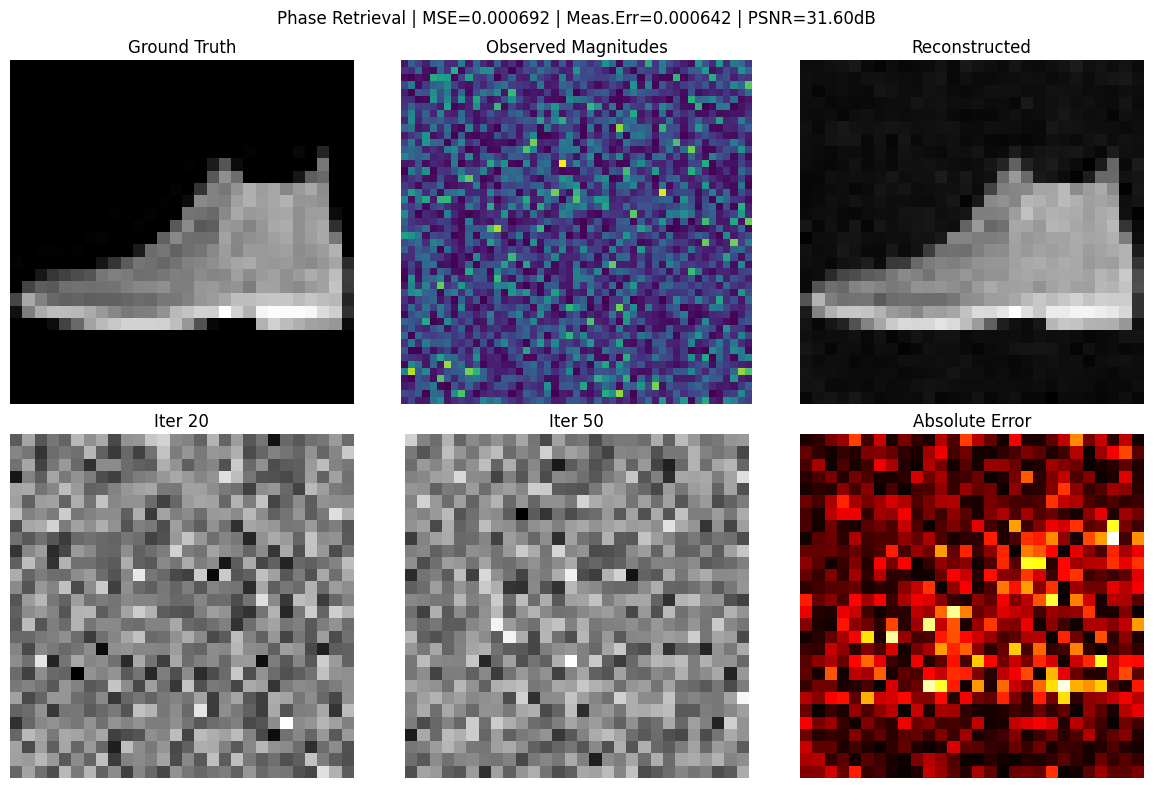

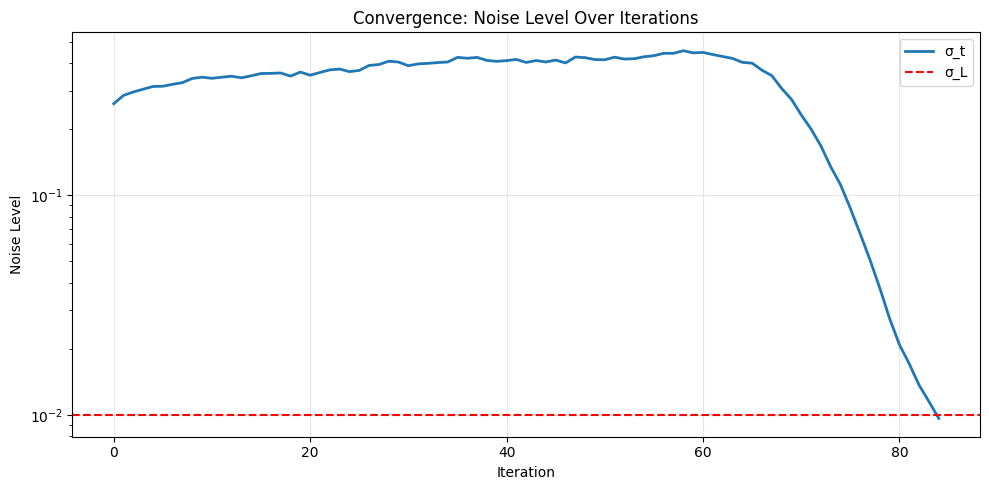

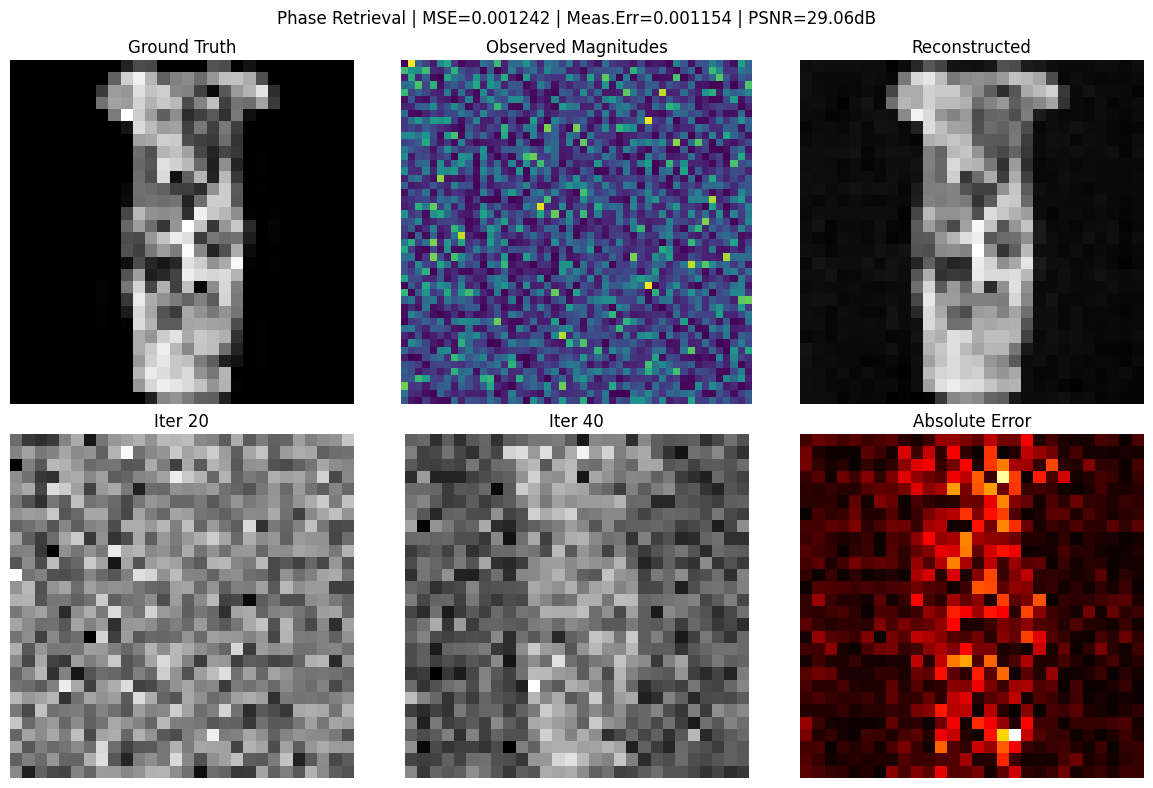

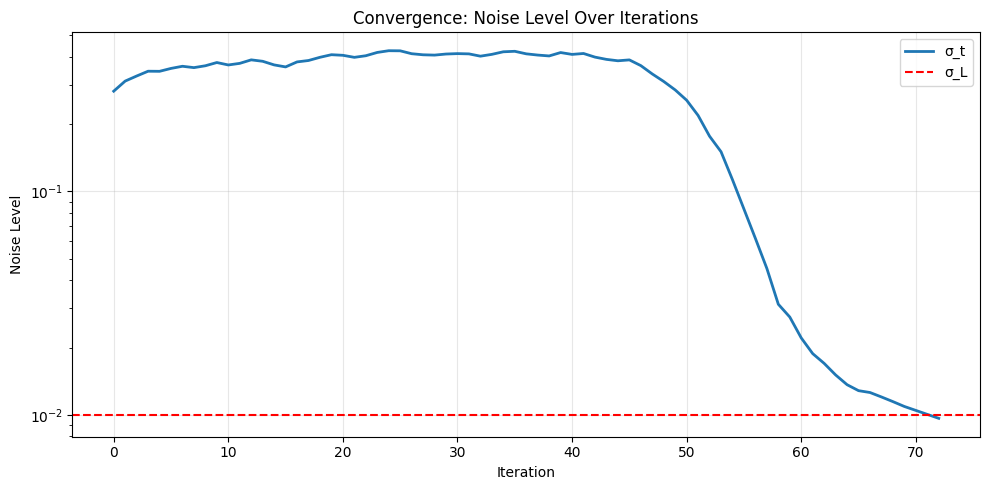

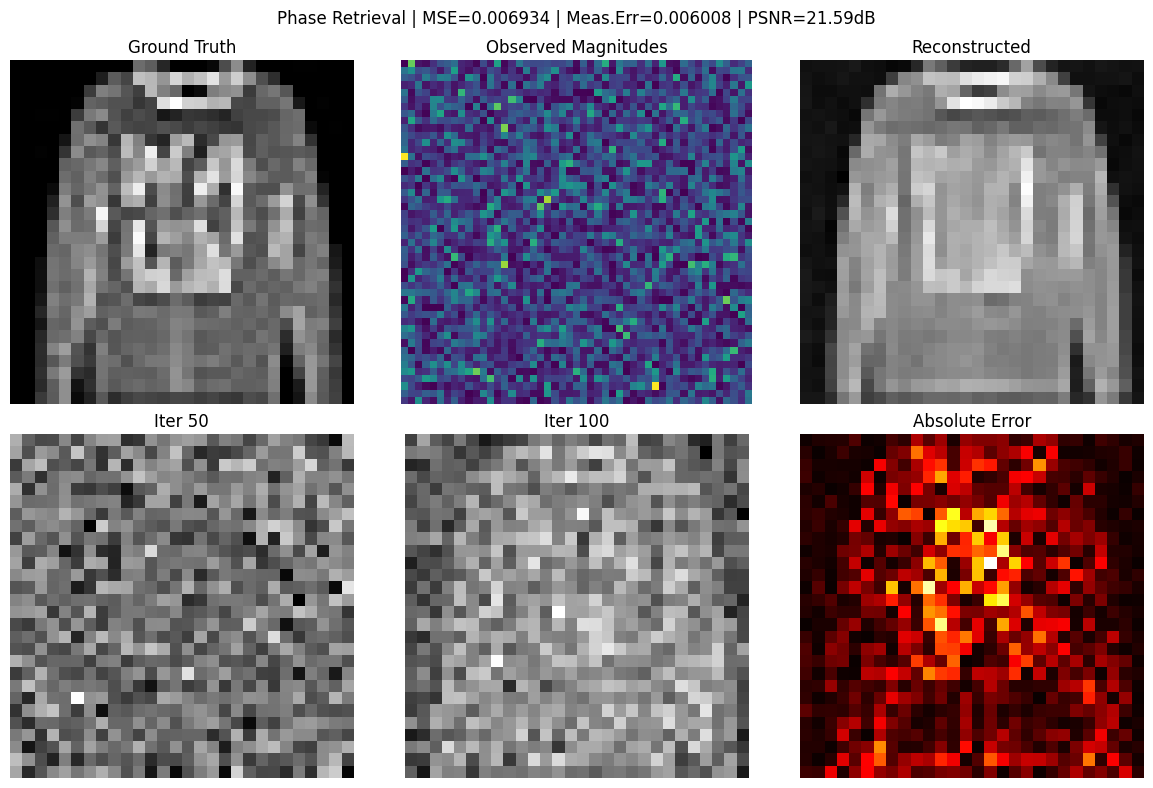

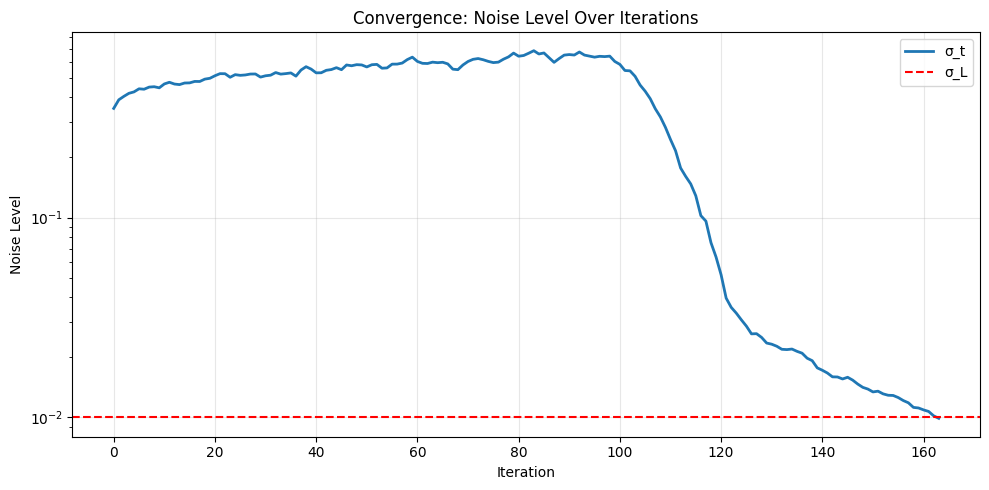

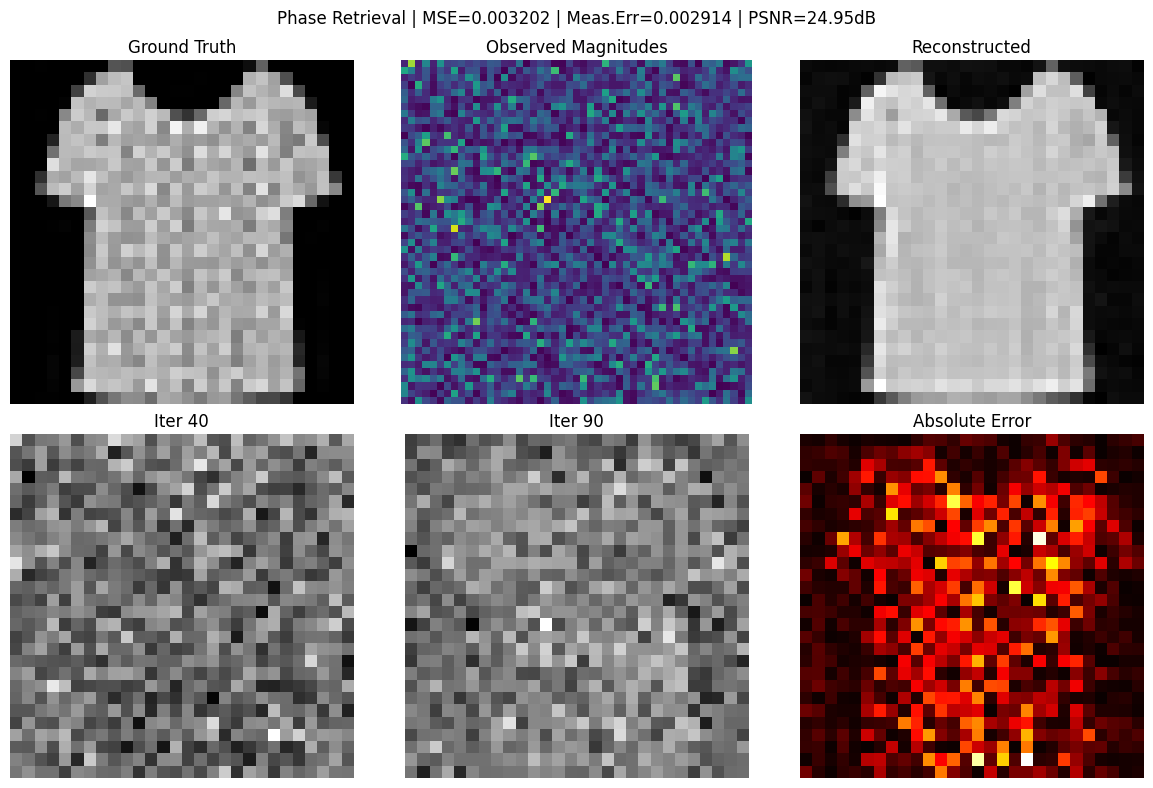

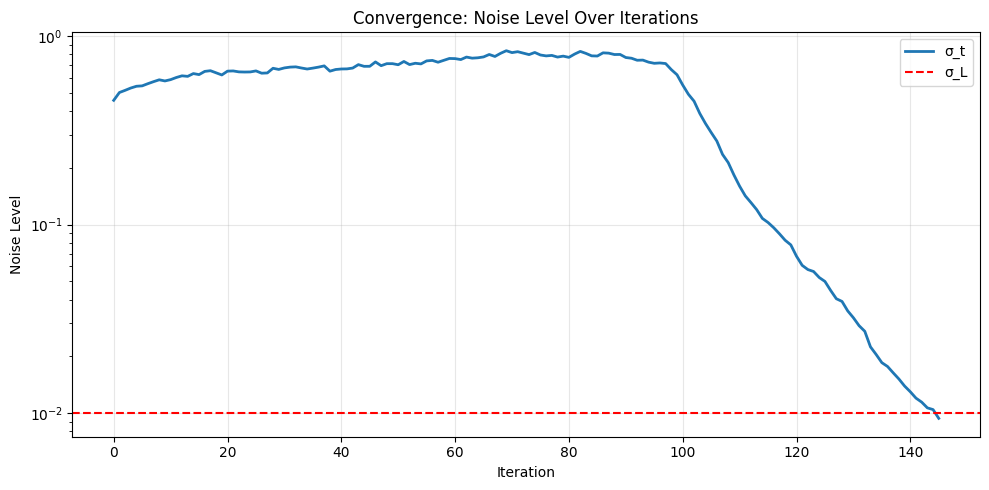

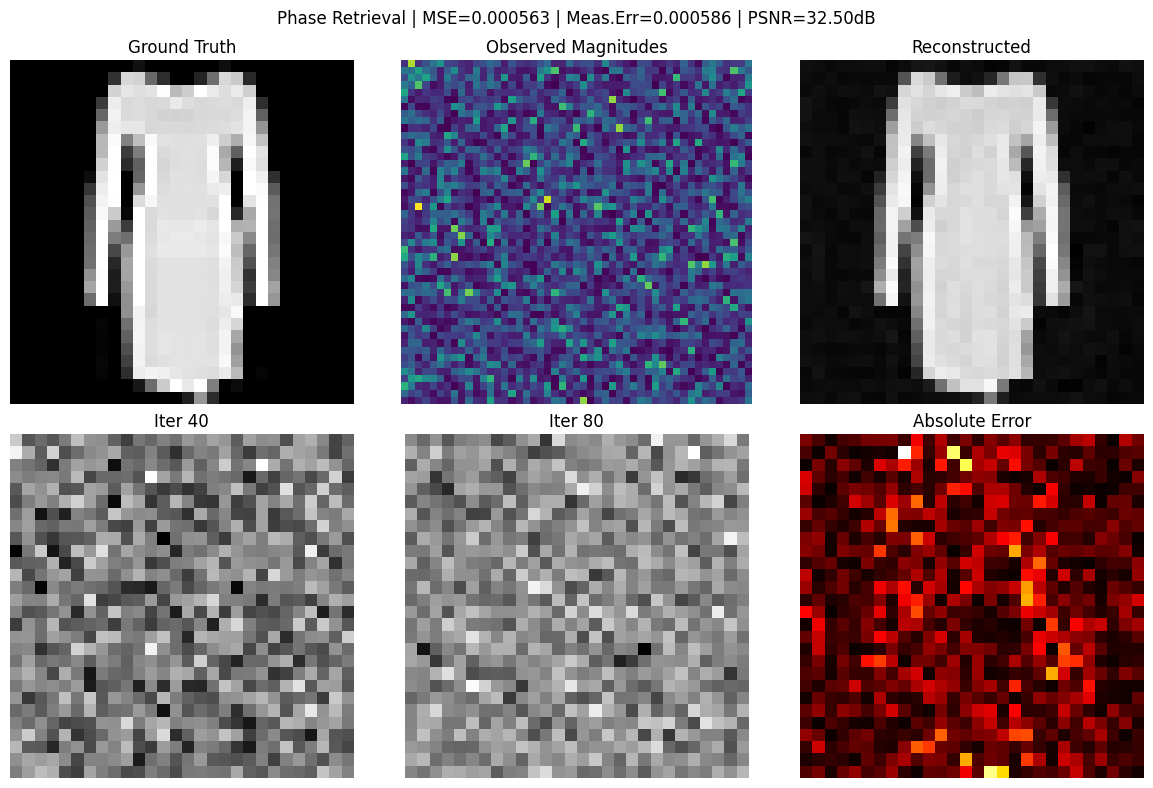

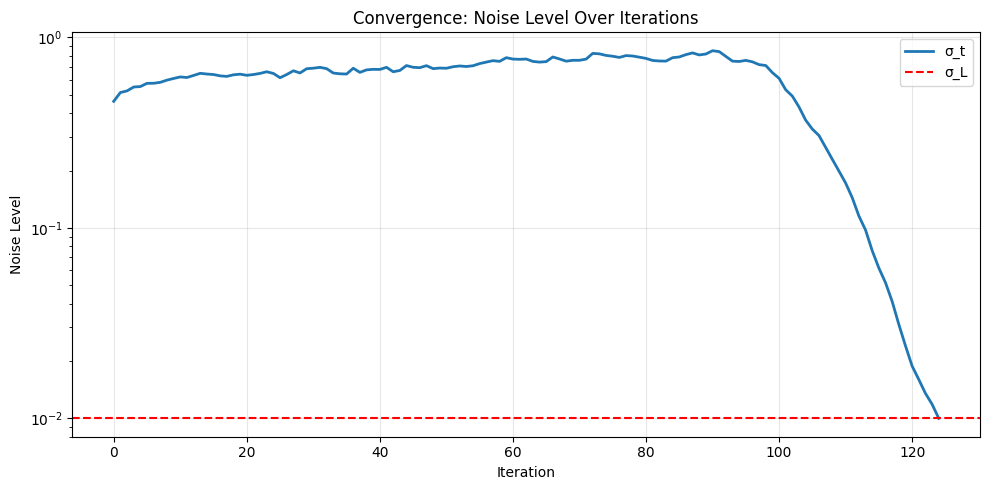

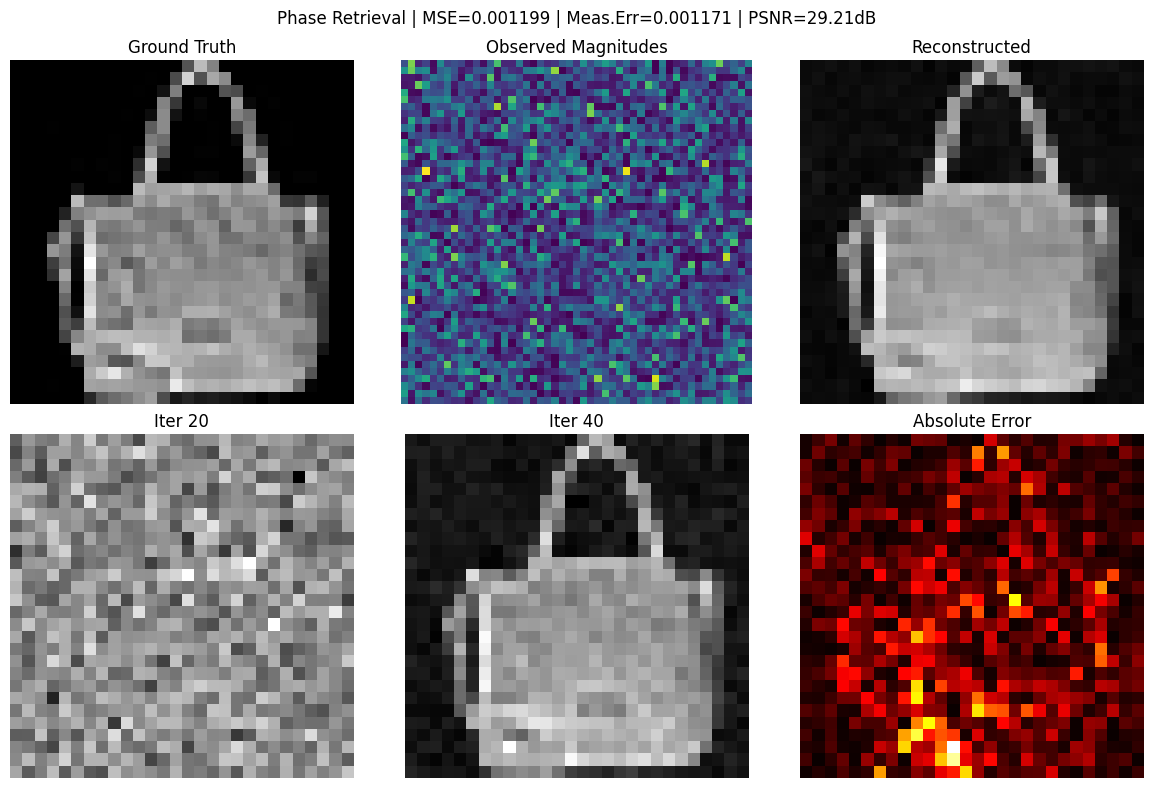

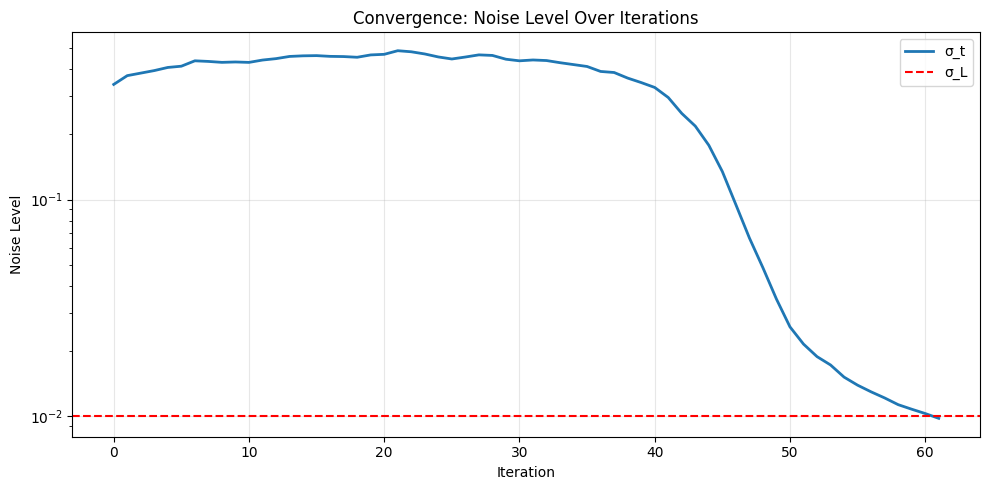

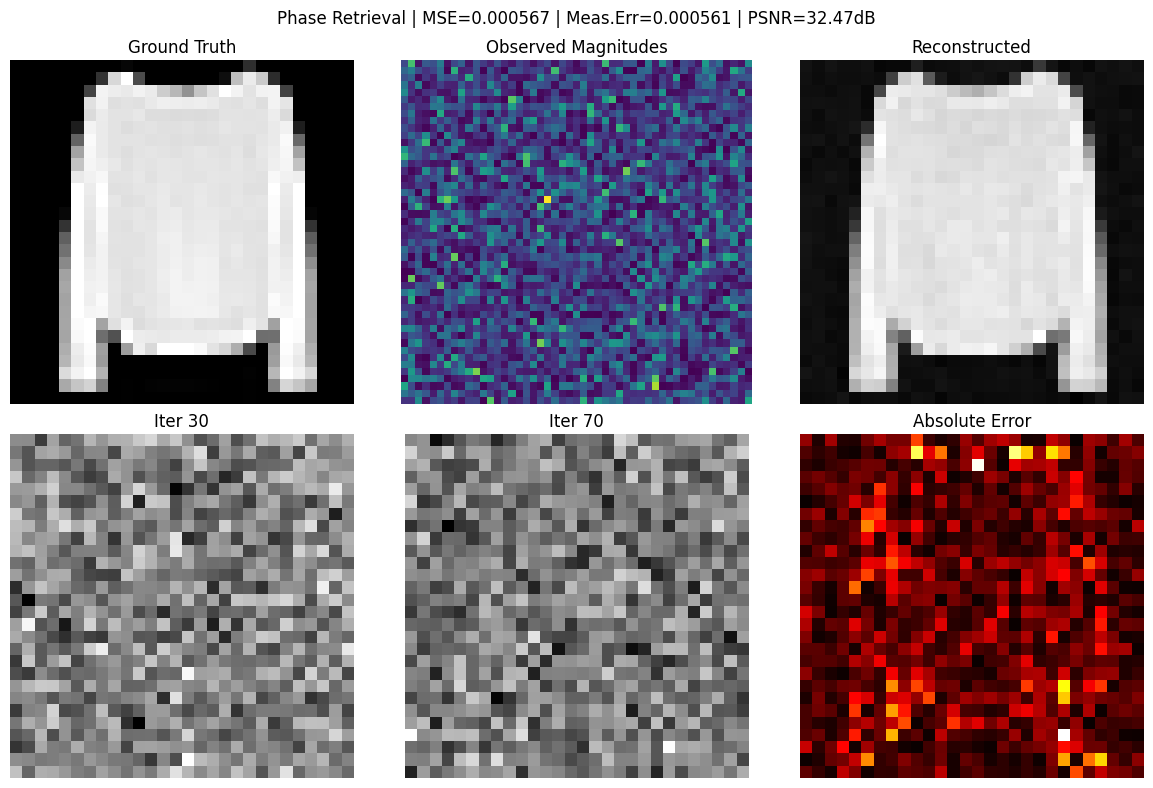

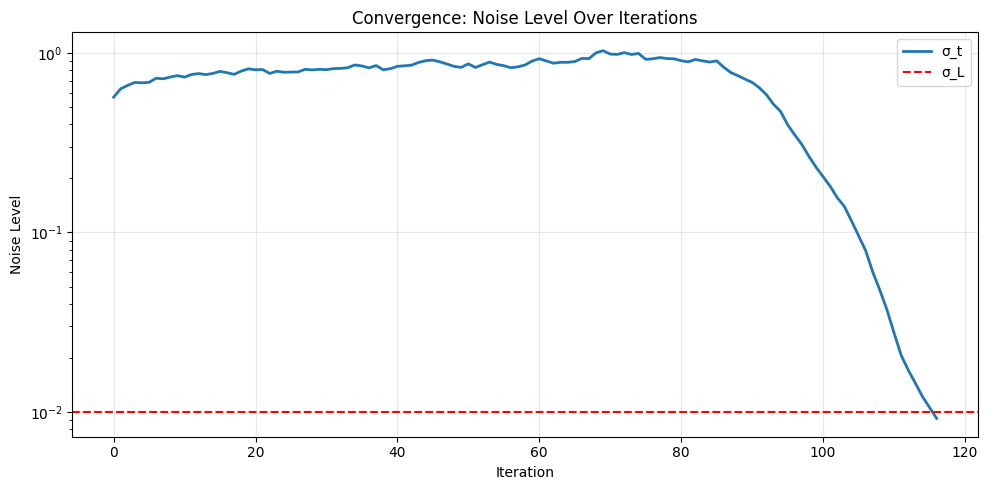

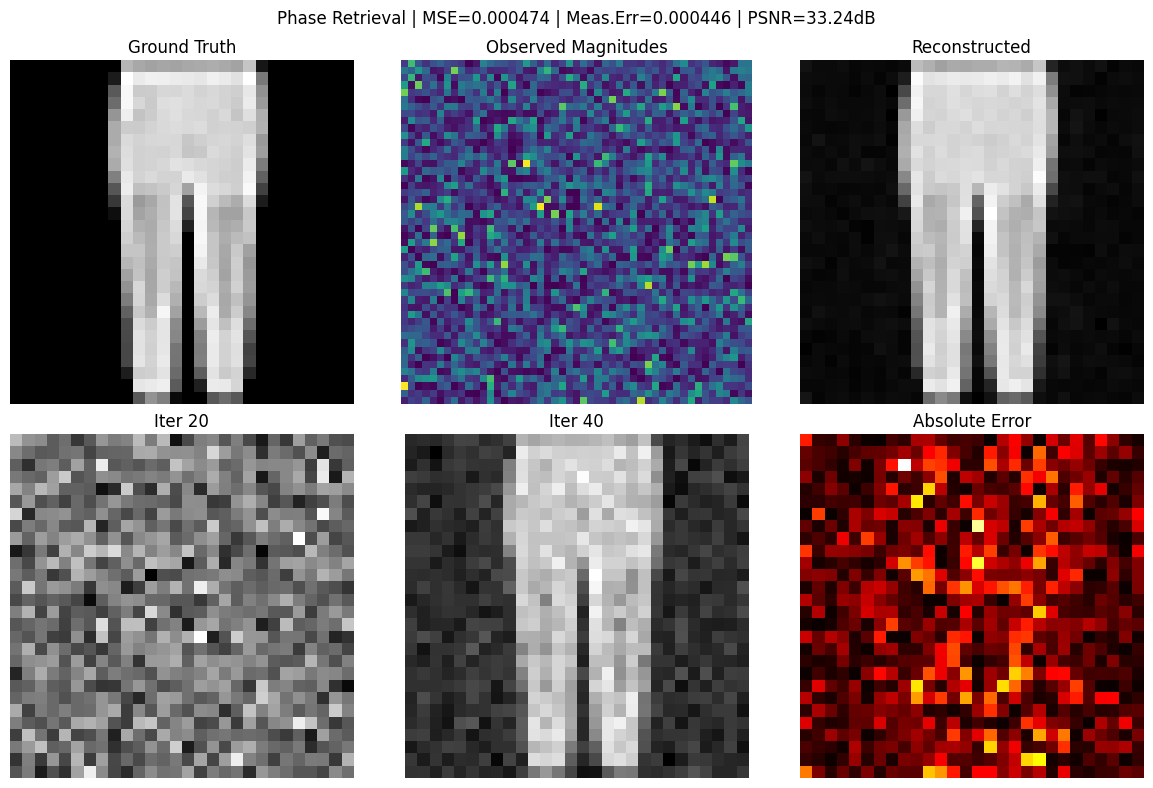

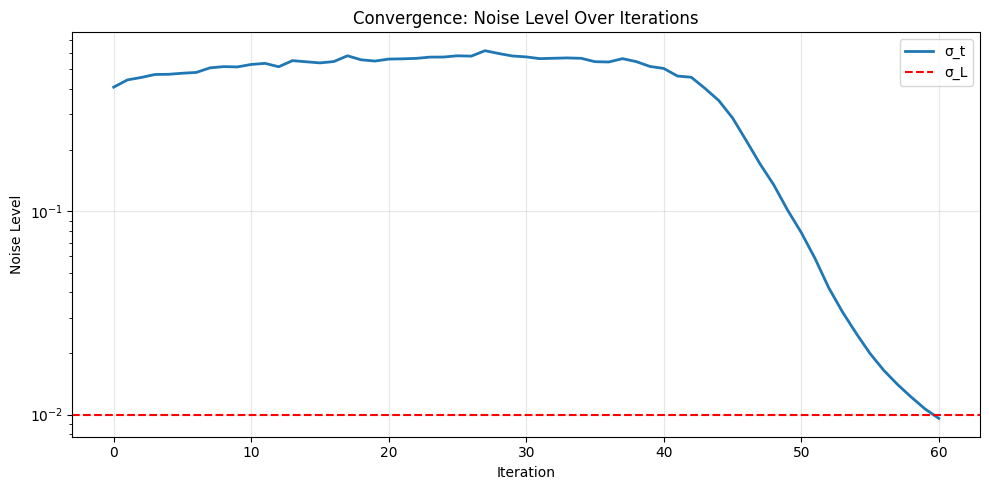

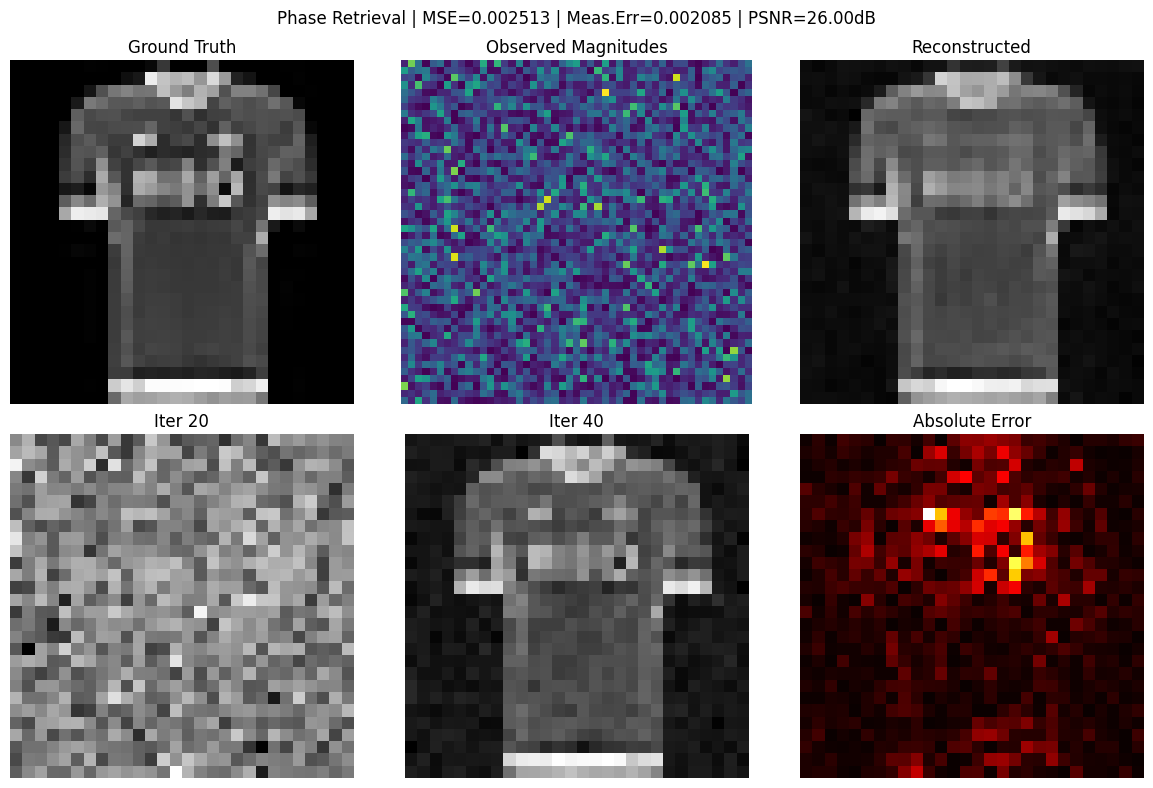

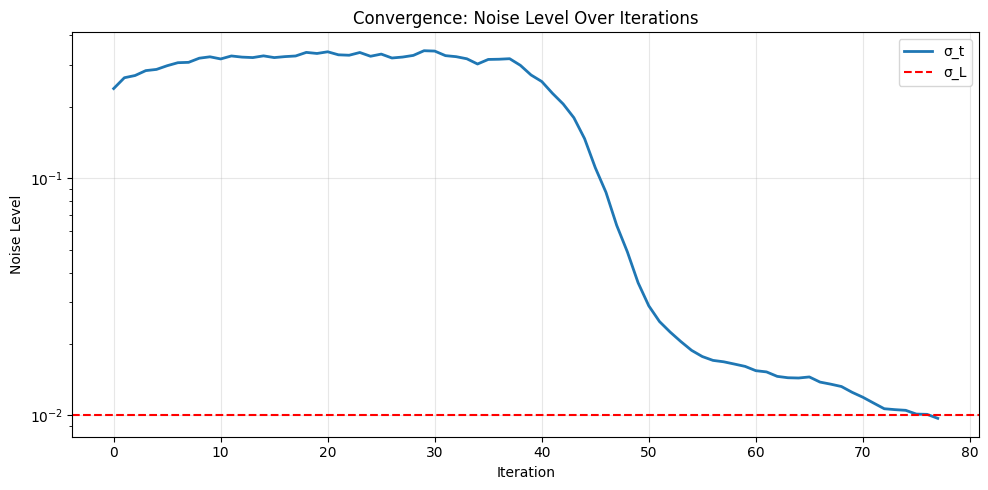

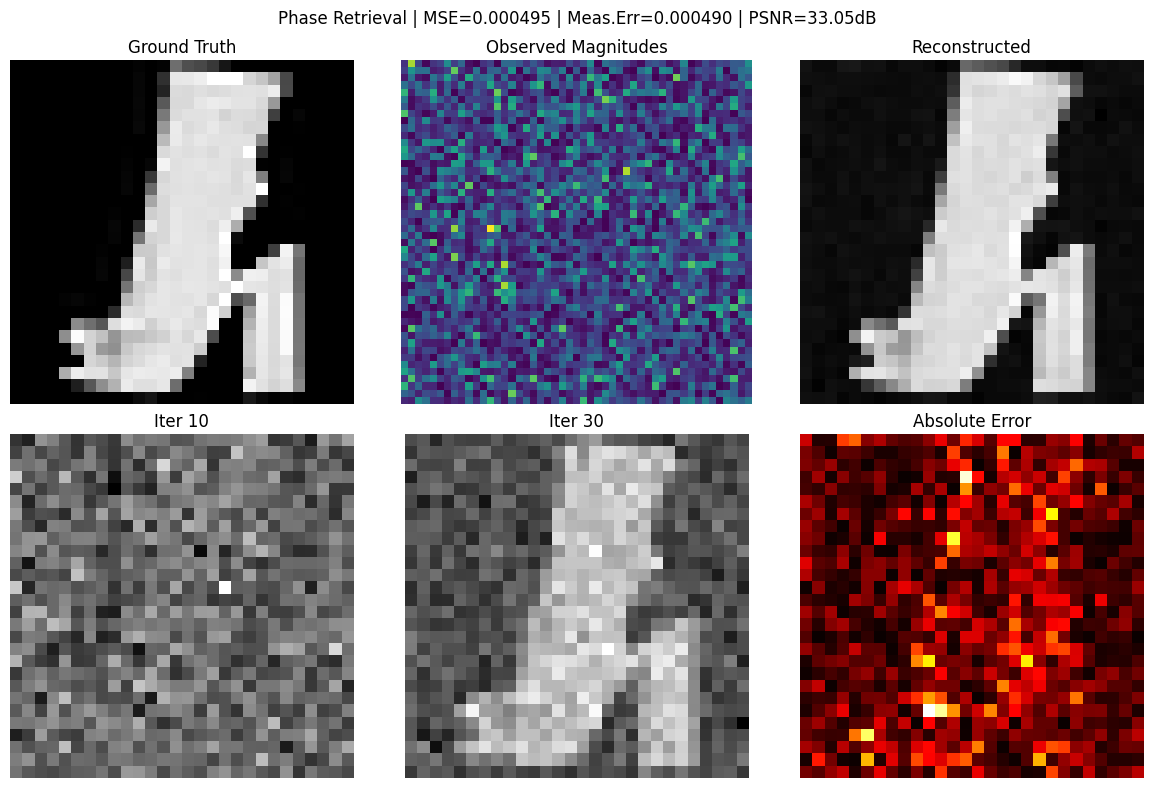

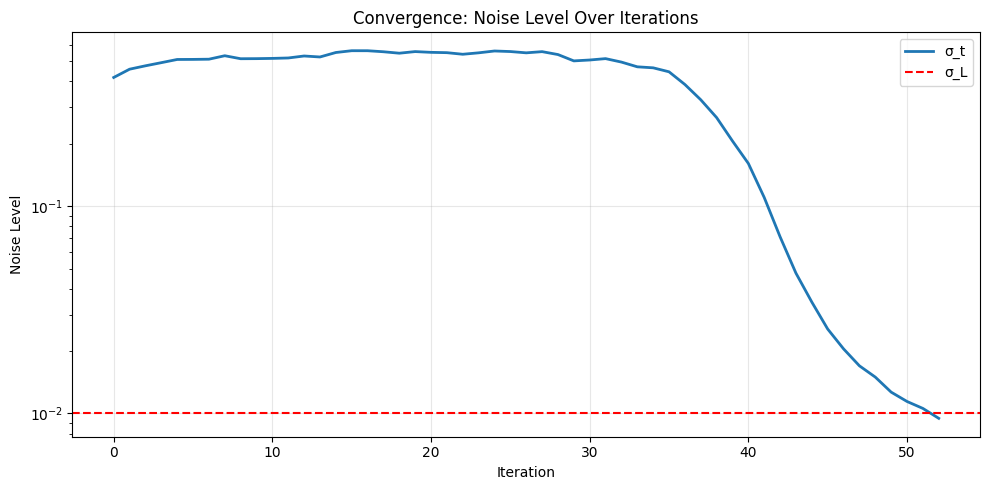

In [77]:
# ========== STEP 3: SETUP PHASE RETRIEVAL TASK ==========
print("\n--- Setting up Phase Retrieval Task ---")

task = PhaseRetrievalTask(
    measurement_dim=config.measurement_dim,
    image_dim=config.n_pixels,
    seed=config.seed_measurement,
    device=config.device
)

# ========== STEP 4: TEST ON SAMPLE IMAGES ==========
print("\n--- Running Phase Retrieval on Test Images ---")

# Select a few test images
test_indices = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 3500, 3999]
all_results = []

for idx in test_indices:
    print(f"\n  Test Image {idx}:")
    
    # Get test image
    x_test, _ = val_dataset[idx]  # [1, 28, 28]
    x_test = x_test.view(-1)  # Flatten to [784]
    
    # Generate measurements
    b_test = task.get_magnitudes(x_test.to(config.device))
    
    # Run phase retrieval
    x_recon, pr_results = phase_retrieval_algorithm(
        denoiser, task, b_test, config, test_ground_truth=x_test
    )
    
    # Evaluate
    pr_results['evaluation'] = evaluate_reconstruction(
        x_recon.to(config.device), x_test.to(config.device), task.A, b_test
    )

    # Corriger le signe si nécessaire
    mse_original = pr_results['evaluation']['mse_image']
    x_recon_flipped = -x_recon
    eval_flipped = evaluate_reconstruction(
        x_recon_flipped.to(config.device), x_test.to(config.device), task.A, b_test
    )
    mse_flipped = eval_flipped['mse_image']

    if mse_flipped < mse_original:
        x_recon = x_recon_flipped
        pr_results['evaluation'] = eval_flipped
        print(f"    Sign corrected (MSE improved from {mse_original:.6f} to {mse_flipped:.6f})")
    
    all_results.append({
        'test_idx': idx,
        'x_ground_truth': x_test,
        'x_reconstructed': x_recon,
        'measurements': b_test.cpu(),
        'results': pr_results,
    })
    
    print(
        f"    MSE: {pr_results['evaluation']['mse_image']:.6f} | "
        f"Meas.Err: {pr_results['evaluation']['measurement_error']:.6f} | "
        f"PSNR: {pr_results['evaluation']['psnr']:.2f} dB | "
        f"Iterations: {pr_results['iterations']}"
    )
    
    # Visualize
    save_dir = config.save_dir / f"test_{idx}"
    save_dir.mkdir(exist_ok=True)
    visualize_results(
        x_test, x_recon, b_test.cpu(),
        pr_results['intermediates'], {**pr_results['evaluation'], 'sigma_trajectory': pr_results['sigma_trajectory']},
        save_dir, config.image_size
    )

# ========== STEP 5: SAVE SUMMARY ==========
print("\n--- Saving Results Summary ---")

summary = {
    'config': {
        'oversample_ratio': config.oversample_ratio,
        'measurement_dim': config.measurement_dim,
        'image_dim': config.n_pixels,
        'sigma_0': config.sigma_0,
        'sigma_L': config.sigma_L,
        'h0': config.h0,
        'beta': config.beta,
    },
    'denoiser_final_val_loss': denoiser_history['val_loss'][-1] if denoiser_history['val_loss'] else None,
    'test_results': [
        {
            'idx': r['test_idx'],
            'mse': r['results']['evaluation']['mse_image'],
            'meas_error': r['results']['evaluation']['measurement_error'],
            'iterations': r['results']['iterations'],
        }
        for r in all_results
    ]
}

with open(config.save_dir / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Saved summary to {config.save_dir / 'summary.json'}")
print("=" * 70)
print("EXPERIMENT COMPLETE")
print("=" * 70)


--- Test Visuel du Denoiser ---

Image 0 - Label: 9


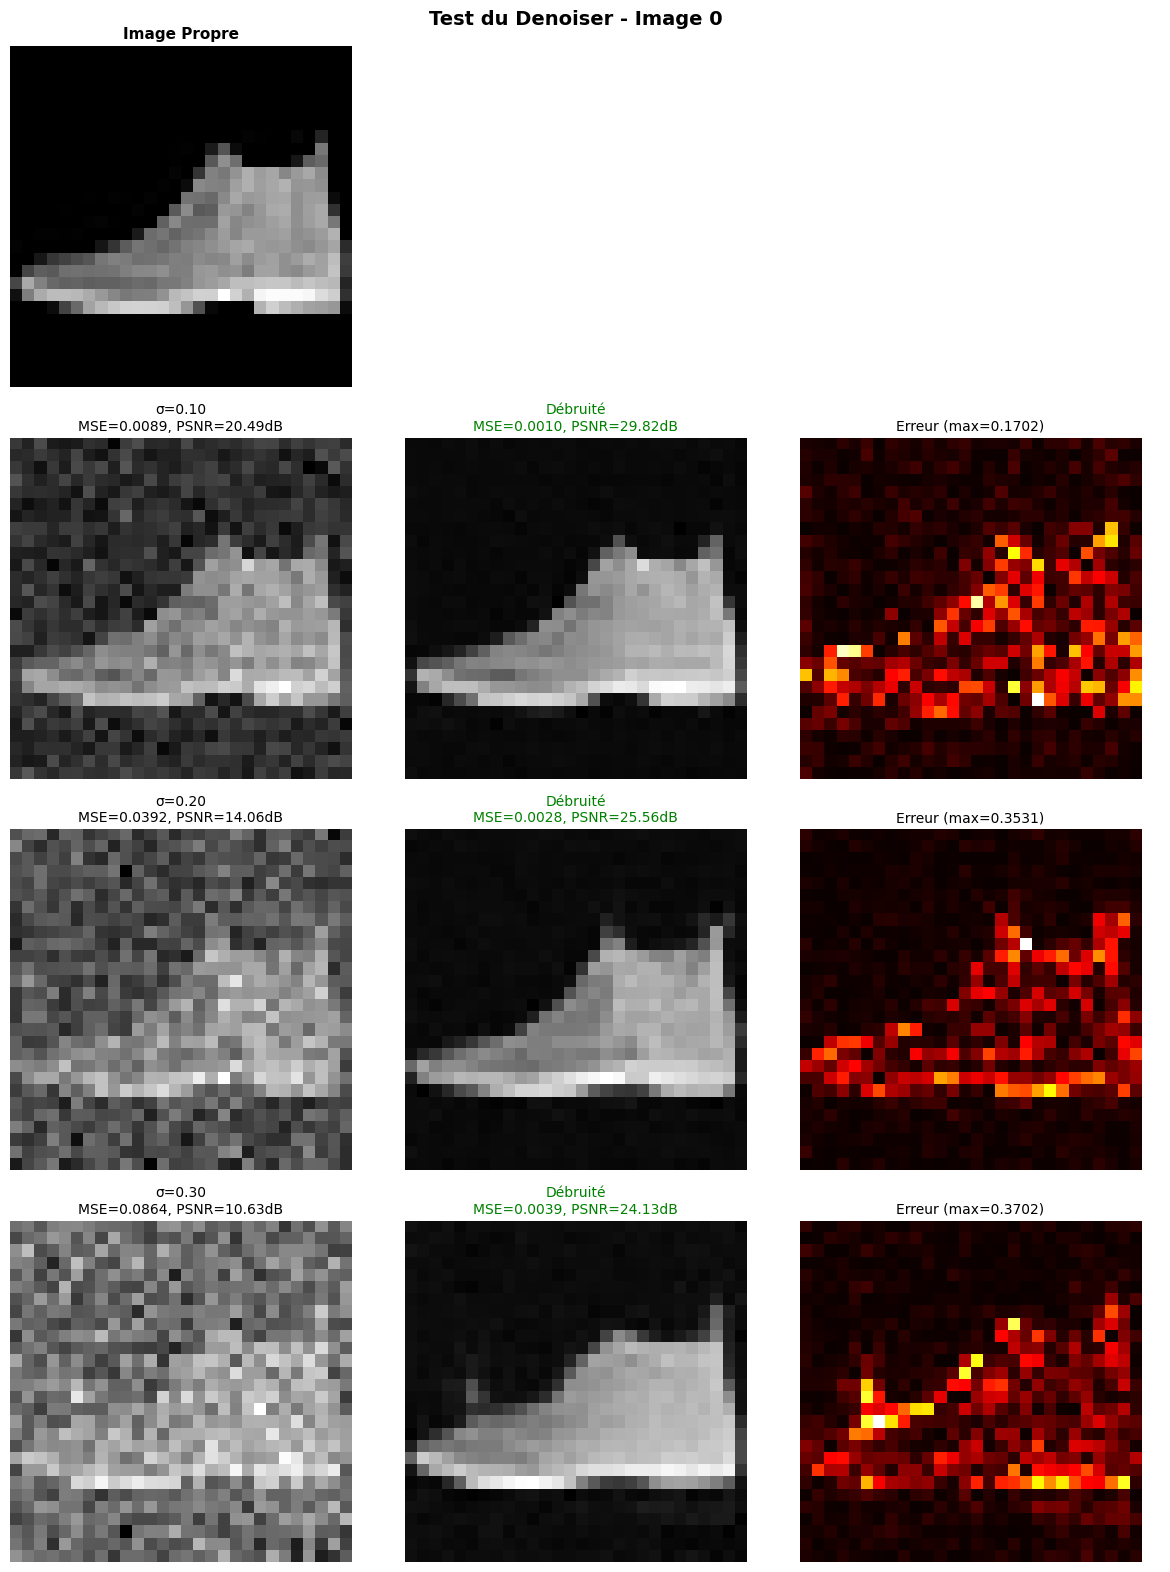

Image 50 - Label: 4


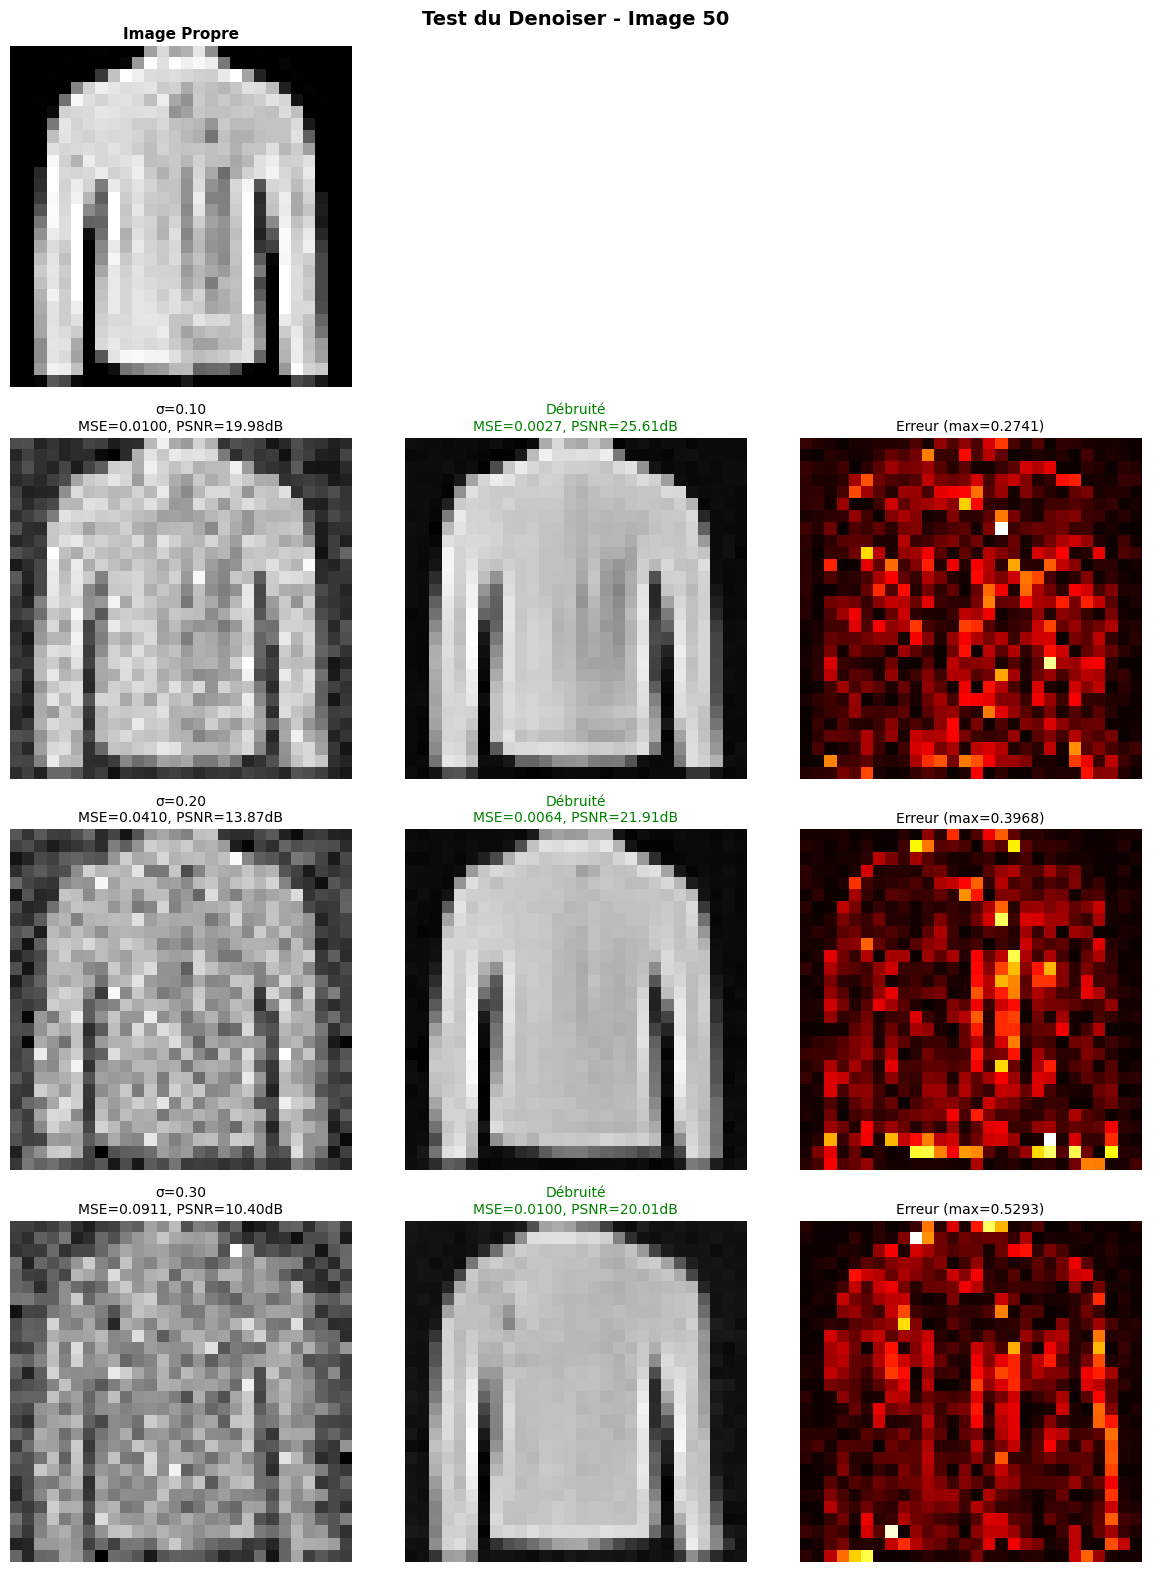

Image 100 - Label: 3


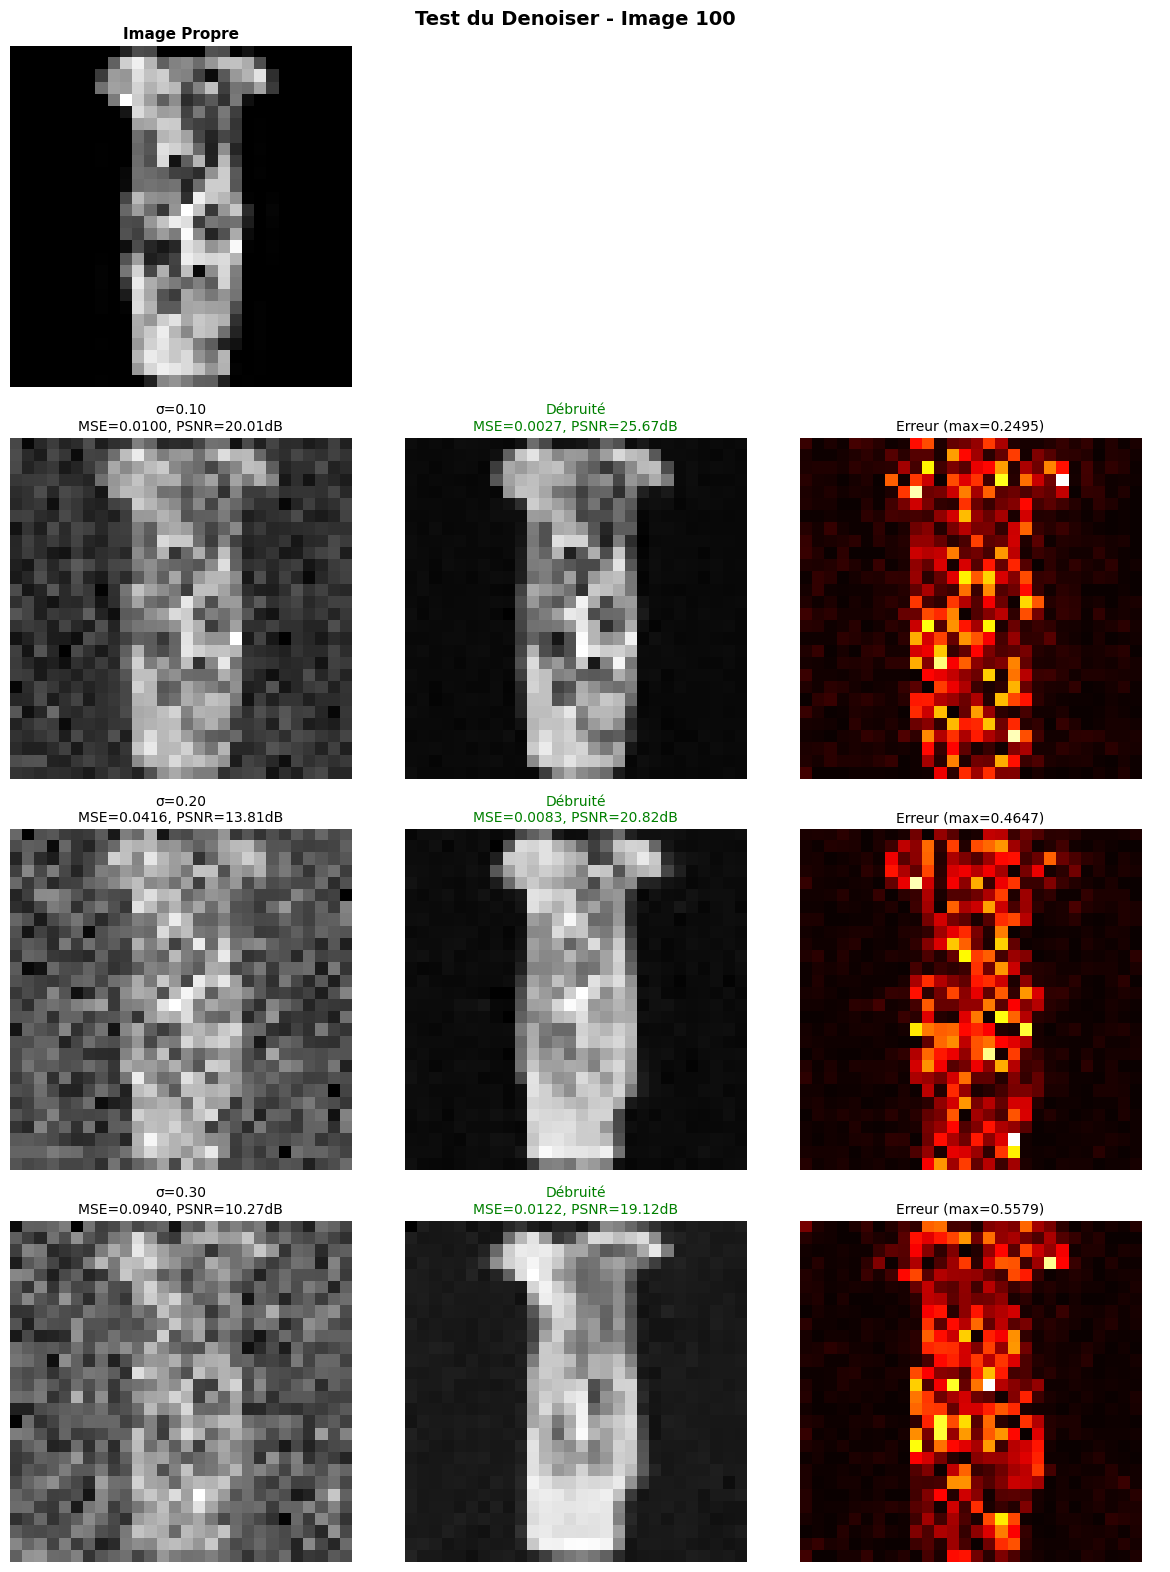

In [70]:
# ============================================================================
# TEST VISUEL DU DENOISER
# ============================================================================

print("\n--- Test Visuel du Denoiser ---\n")

# Test sur 3 images
test_indices = [0, 50, 100]
noise_levels = [0.1, 0.2, 0.3]

for test_idx in test_indices:
    # Récupérer une image du dataset
    x_clean, label = val_dataset[test_idx]
    x_clean = x_clean.to(config.device)  # [1, 28, 28]
    
    print(f"Image {test_idx} - Label: {label}")
    
    # Créer une figure avec sous-plots
    fig, axes = plt.subplots(
        len(noise_levels) + 1, 3, 
        figsize=(12, 4 * (len(noise_levels) + 1))
    )
    
    # Afficher l'image propre
    axes[0, 0].imshow(x_clean.squeeze().cpu(), cmap='gray')
    axes[0, 0].set_title('Image Propre', fontsize=11, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].text(0.5, 0.5, '', ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].axis('off')
    
    axes[0, 2].text(0.5, 0.5, '', ha='center', va='center', transform=axes[0, 2].transAxes)
    axes[0, 2].axis('off')
    
    # Tester avec différents niveaux de bruit
    denoiser.eval()
    with torch.no_grad():
        for i, sigma in enumerate(noise_levels, 1):
            # Ajouter du bruit
            noise = torch.randn_like(x_clean) * sigma
            x_noisy = x_clean + noise
            x_noisy_input = x_noisy.unsqueeze(0)
            
            # Débruiter
            x_denoised = denoiser(x_noisy_input)
            
            # Calculer les métriques
            mse_noisy = torch.mean((x_noisy - x_clean) ** 2).item()
            mse_denoised = torch.mean((x_denoised - x_clean) ** 2).item()
            psnr_noisy = 10 * np.log10(1.0 / mse_noisy) if mse_noisy > 0 else 0
            psnr_denoised = 10 * np.log10(1.0 / mse_denoised) if mse_denoised > 0 else 0
            
            # Afficher les résultats
            # Colonne 1: Image bruitée
            axes[i, 0].imshow(x_noisy.squeeze().cpu(), cmap='gray')
            axes[i, 0].set_title(
                f'σ={sigma:.2f}\nMSE={mse_noisy:.4f}, PSNR={psnr_noisy:.2f}dB',
                fontsize=10
            )
            axes[i, 0].axis('off')
            
            # Colonne 2: Image débruité
            axes[i, 1].imshow(x_denoised.squeeze().cpu(), cmap='gray')
            axes[i, 1].set_title(
                f'Débruité\nMSE={mse_denoised:.4f}, PSNR={psnr_denoised:.2f}dB',
                fontsize=10,
                color='green' if mse_denoised < mse_noisy else 'red'
            )
            axes[i, 1].axis('off')
            
            # Colonne 3: Différence absolue (erreur)
            error = torch.abs(x_denoised - x_clean)
            axes[i, 2].imshow(error.squeeze().cpu(), cmap='hot')
            axes[i, 2].set_title(f'Erreur (max={error.max():.4f})', fontsize=10)
            axes[i, 2].axis('off')
    
    plt.suptitle(f'Test du Denoiser - Image {test_idx}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


TEST SUR INPAINTING (PROBLÈME LINÉAIRE)
Inpainting mask created: 12.8% de pixels masqués

--- Test Image 0 (Inpainting) ---
Initial MSE: 0.980259
Iter  10 | σ=0.949273 | h=0.091743 | γ=0.395102 | MSE=0.907177
Iter  20 | σ=0.936979 | h=0.168067 | γ=0.517064 | MSE=0.925378
Iter  30 | σ=0.941311 | h=0.232558 | γ=0.600072 | MSE=0.893523
Iter  40 | σ=0.874354 | h=0.287770 | γ=0.610159 | MSE=0.708767
Iter  50 | σ=0.719064 | h=0.335570 | γ=0.534160 | MSE=0.518487
Iter  60 | σ=0.618489 | h=0.377358 | γ=0.480986 | MSE=0.384185
Iter  70 | σ=0.581016 | h=0.414201 | γ=0.467915 | MSE=0.341868
Iter  80 | σ=0.483660 | h=0.446927 | γ=0.400356 | MSE=0.264438
Iter  90 | σ=0.505332 | h=0.476190 | γ=0.427632 | MSE=0.281146
Iter 100 | σ=0.463107 | h=0.502513 | γ=0.399047 | MSE=0.220930
Iter 110 | σ=0.387025 | h=0.526316 | γ=0.338537 | MSE=0.152263
Iter 120 | σ=0.366630 | h=0.547945 | γ=0.324776 | MSE=0.140093
Iter 130 | σ=0.307502 | h=0.567686 | γ=0.275345 | MSE=0.101782
Iter 140 | σ=0.289400 | h=0.585774

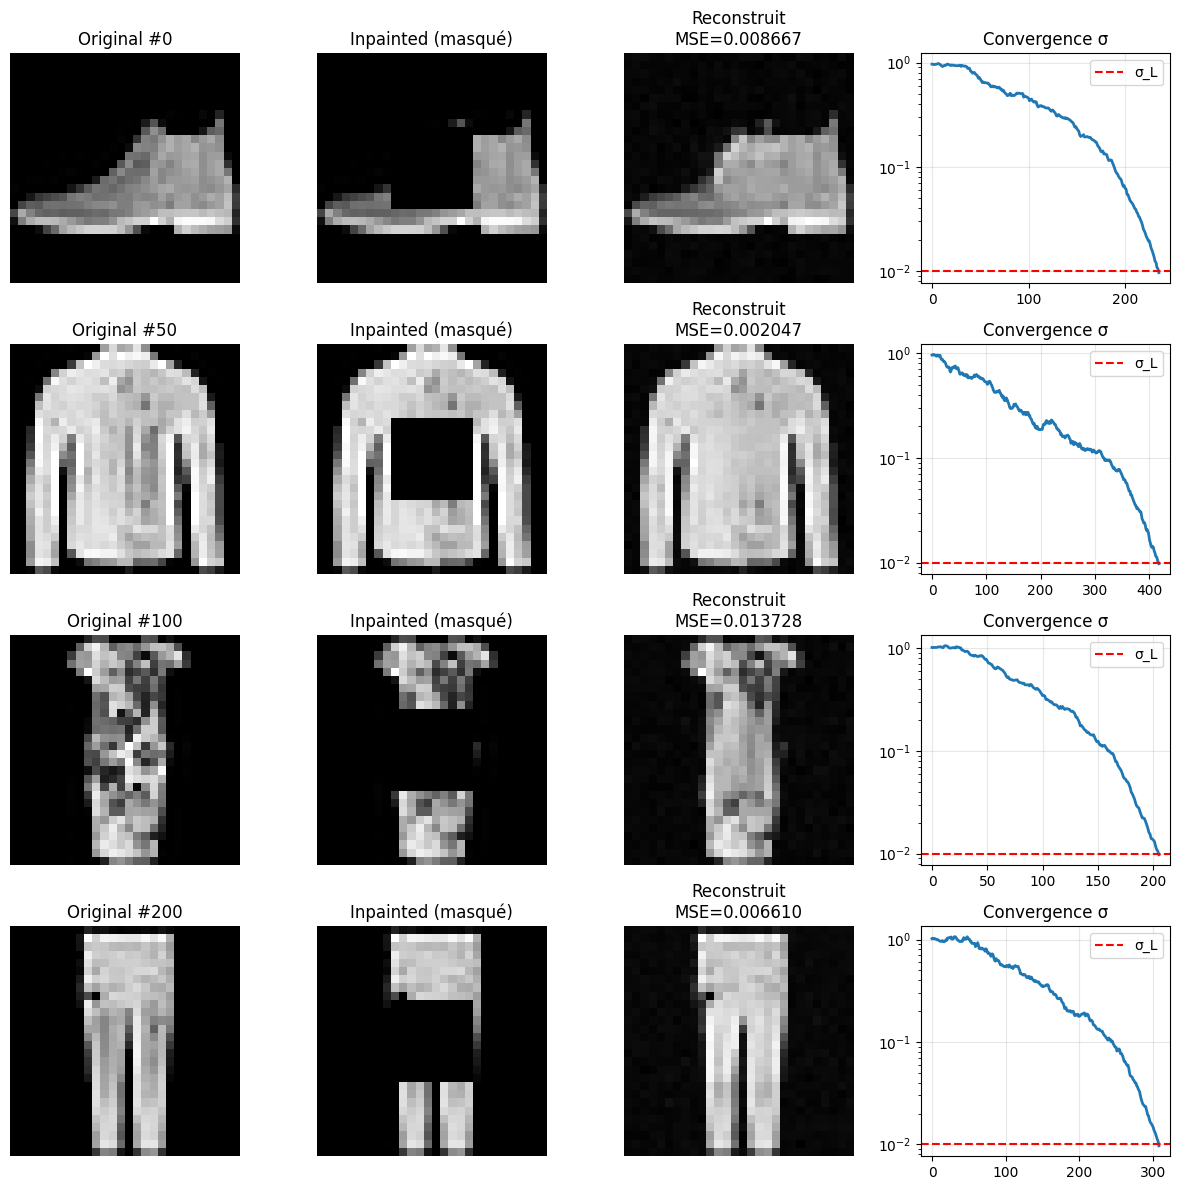


RÉSUMÉ INPAINTING
Image   0: MSE=0.008667, Iter=235, σ_final=0.009698
Image  50: MSE=0.002047, Iter=418, σ_final=0.009739
Image 100: MSE=0.013728, Iter=205, σ_final=0.009741
Image 200: MSE=0.006610, Iter=308, σ_final=0.009679


In [69]:
# ============================================================================
# OPERATEURS LINEAIRES POUR PROBLÈMES INVERSES
# ============================================================================

class InpaintingOperator:
    """
    Opérateur d'inpainting: masque une région centrale de l'image.
    
    M: application du masque (observations)
    M_T: adjoint (restauration)
    """
    def __init__(self, x_size, mask_frac=0.25, device="cpu"):
        """
        Args:
            x_size: (n_ch, im_d1, im_d2)
            mask_frac: fraction du centre à masquer
            device: "cpu" ou "cuda"
        """
        self.x_size = x_size
        self.device = device
        n_ch, im_d1, im_d2 = x_size
        
        # Créer le masque (1 = gardé, 0 = masqué)
        self.mask = torch.ones(x_size, device=device)
        
        # Masquer le centre
        h_mask = int(im_d1 * np.sqrt(mask_frac) / 2)
        w_mask = int(im_d2 * np.sqrt(mask_frac) / 2)
        c1, c2 = im_d1 // 2, im_d2 // 2
        
        self.mask[:, c1-h_mask:c1+h_mask, c2-w_mask:c2+w_mask] = 0
        
        print(f"Inpainting mask created: {(1-self.mask.mean()).item()*100:.1f}% de pixels masqués")
    
    def M_T(self, x):
        """Adjoint: restaure en gardant les pixels observés"""
        return x * self.mask
    
    def M(self, x):
        """Forward: retourne les observations (pixels non-masqués)"""
        return x * self.mask


class IdentityOperator:
    """Opérateur identité (aide-mémoire)"""
    def __init__(self, x_size, device="cpu"):
        self.device = device
    
    def M_T(self, x):
        return x
    
    def M(self, x):
        return x


# ============================================================================
# ALGORITHME D'INVERSION GÉNÉRIQUE (PAPIER ORIGINAL)
# ============================================================================

def solve_inverse_problem_with_denoiser(
    denoiser: nn.Module,
    operator,  # Objet avec M et M_T
    x_observed,  # Les observations (mesurées)
    config,
    x_ground_truth: torch.Tensor = None,
    sigma_0: float = 1.0,
    sigma_L: float = 0.01,
    h0: float = 0.01,
    beta: float = 0.01,
    verbose: bool = True,
) -> Tuple[torch.Tensor, Dict]:
    """
    Algorithme général pour les problèmes inverses linéaires d'après:
    "Solving Linear Inverse Problems Using the Prior Implicit in a Denoiser"
    (Kadkhodaie & Simoncelli, 2020)
    
    FORMULE CLÉE pour problèmes LINÉAIRES (Algorithme 2):
        d_t = (I - M M^T) f(y_{t-1}) + M(x^c - M^T y_{t-1})
        avec f(y) = D(y) - y
    
    Args:
        denoiser: Denoiser entraîné D(y)
        operator: Objet avec méthodes M(x) et M_T(x)
        x_observed: Données observées M_T(x*)
        config: Configuration
        x_ground_truth: Vérité terrain (optionnelle)
        sigma_0: bruit initial
        sigma_L: bruit final (convergence)
        h0: taille de pas initiale
        beta: paramètre de bruit de Langevin
    
    Returns:
        (x_reconstructed, results_dict)
    """
    device = config.device
    denoiser = denoiser.to(device).eval()
    
    n_ch, im_d1, im_d2 = x_observed.shape
    N = n_ch * im_d1 * im_d2
    
    x_observed = x_observed.to(device)
    
    results = {
        'iterations': 0,
        'sigma_trajectory': [],
        'mse_trajectory': [],
        'intermediates': [],
        'time_per_iter': [],
    }
    
    # ========== INITIALISATION ==========
    # y_0 ~ N(0.5(I - MM^T)e + M x^c, sigma_0^2 I)
    
    # Identifier les zones masquées et observées
    ones = torch.ones_like(x_observed)
    mask = operator.M_T(operator.M(ones))
    missing_mask = ones - mask
    
    # Initialisation de la moyenne: 0.5 sur les pixels manquants, x_observed sur les connus
    y_mean = 0.5 * missing_mask + x_observed
    
    # On ajoute du bruit blanc gaussien sur TOUTE l'image
    z_init = torch.randn_like(x_observed) * sigma_0
    y = y_mean + z_init
    
    # Reshape pour le denoiser [1, n_ch, im_d1, im_d2]
    y_for_denoiser = y.unsqueeze(0) if y.dim() == 3 else y
    
    if x_ground_truth is not None:
        x_ground_truth = x_ground_truth.to(device)
        mse = torch.norm(y - x_ground_truth).item() ** 2 / N
        results['mse_trajectory'].append(mse)
        if verbose:
            print(f"Initial MSE: {mse:.6f}")
            
    # ========== BOUCLE PRINCIPALE ==========
    t = 1
    time_start = time.time()
    sigma_t = sigma_0  # Correction: on traque sigma_t pour la condition d'arrêt
    
    while sigma_t >= sigma_L and t <= config.max_iterations:
        # Step 1: Calculer le débruitage
        with torch.no_grad():
            y_denoised = denoiser(y_for_denoiser)
        
        if y_denoised.dim() == 4:
            y_denoised = y_denoised.squeeze(0)
        
        # Step 2: Formule générale de l'Algorithme 2
        # d_t = (I - M M^T) f(y_{t-1}) + M(x^c - M^T y_{t-1})
        
        # Le résidu du débruiteur: f(y) = D(y) - y
        f_y = y_denoised - y
        
        # 1er terme: Projection du résidu sur l'espace non-mesuré (I - MM^T)f(y)
        P_f_y = operator.M_T(operator.M(f_y))
        term1 = f_y - P_f_y
        
        # 2ème terme: Écart avec la contrainte M(x^c - M^T y)
        P_y = operator.M_T(operator.M(y))
        term2 = x_observed - P_y  # x_observed est déjà M x^c
        
        d = term1 + term2
        
        # Estimer le bruit effectif
        sigma_t = torch.norm(d).item() / np.sqrt(N)
        results['sigma_trajectory'].append(sigma_t)
        
        if sigma_t < sigma_L:
            if verbose:
                print(f"Converged at iteration {t}: σ_t = {sigma_t:.6f} < σ_L = {sigma_L}")
            break
        
        # Step 3: Taille de pas adaptative
        h_t = h0 * t / (1 + h0 * (t - 1))
        
        # Step 4: Gradient Ascent (+)
        y = y + h_t * d  
        
        # Step 5: Injection du Bruit de Langevin
        gamma_squared = ((1 - beta * h_t) ** 2 - (1 - h_t) ** 2) * (sigma_t ** 2)
        gamma_t = np.sqrt(max(gamma_squared, 0.0))
        
        noise = torch.randn_like(y) * gamma_t
        y = y + noise
        
        # Reshape pour denoiser pour la prochaine itération
        y_for_denoiser = y.unsqueeze(0) if y.dim() == 3 else y
        
        # Tracking
        if x_ground_truth is not None:
            mse = torch.norm(y - x_ground_truth).item() ** 2 / N
            results['mse_trajectory'].append(mse)
        
        if t % config.save_intermediates_freq == 0:
            results['intermediates'].append(y.cpu().clone())
            elapsed = time.time() - time_start
            results['time_per_iter'].append(elapsed / t)
            
            log_str = f"Iter {t:3d} | σ={sigma_t:.6f} | h={h_t:.6f} | γ={gamma_t:.6f}"
            if x_ground_truth is not None:
                log_str += f" | MSE={mse:.6f}"
            if verbose:
                print(log_str)
        
        t += 1
        
    results['iterations'] = t - 1
    results['total_time'] = time.time() - time_start
    
    if verbose:
        print(f"Finished in {results['iterations']} iterations ({results['total_time']:.2f}s)")
        
    return y.detach().cpu(), results


# ============================================================================
# TEST SUR INPAINTING (PROBLÈME LINÉAIRE)
# ============================================================================

print("\n" + "="*70)
print("TEST SUR INPAINTING (PROBLÈME LINÉAIRE)")
print("="*70)

# Configuration pour inpainting
config_inpaint = type('Config', (), {
    'device': config.device,
    'image_size': 28,
    'max_iterations': 500,
    'save_intermediates_freq': 10,
})()

# Opérateur d'inpainting
inpaint_op = InpaintingOperator(
    x_size=(1, 28, 28),
    mask_frac=0.15,
    device=config.device
)

# Tester sur quelques images
test_indices_inpaint = [0, 50, 100, 200]
results_inpaint = []

for idx in test_indices_inpaint:
    print(f"\n--- Test Image {idx} (Inpainting) ---")
    
    # Charger l'image
    x_true, _ = val_dataset[idx]  # [1, 28, 28]
    if x_true.shape[0] == 1:
        x_true = x_true.squeeze(0).unsqueeze(0)  # Assurer [1, 28, 28]
    
    # Générer observations (appliquer le masque)
    x_observed = inpaint_op.M_T(x_true.to(config.device))
    
    # Résoudre
    x_recon, pr_results = solve_inverse_problem_with_denoiser(
        denoiser,
        inpaint_op,
        x_observed,
        config_inpaint,
        x_ground_truth=x_true.squeeze(0),
        sigma_0=1.0,
        sigma_L=0.01,
        h0=0.01,
        beta=0.01,
    )
    
    # Évaluer
    mse = torch.norm(x_recon - x_true.cpu().squeeze(0)).item() ** 2 / (28*28)
    
    results_inpaint.append({
        'idx': idx,
        'x_true': x_true.squeeze(0),
        'x_observed': x_observed.cpu().squeeze(0),
        'x_recon': x_recon.squeeze(0),
        'results': pr_results,
        'mse': mse,
    })
    
    print(f"  Final MSE: {mse:.6f}")
    print(f"  Iterations: {pr_results['iterations']}")
    print(f"  σ final: {pr_results['sigma_trajectory'][-1] if pr_results['sigma_trajectory'] else 'N/A'}")


# ============================================================================
# VISUALISATION
# ============================================================================

fig, axes = plt.subplots(len(results_inpaint), 4, figsize=(12, 3*len(results_inpaint)))

for i, res in enumerate(results_inpaint):
    # Image originale
    axes[i, 0].imshow(res['x_true'].cpu().numpy(), cmap='gray')
    axes[i, 0].set_title(f"Original #{res['idx']}")
    axes[i, 0].axis('off')
    
    # Image avec inpainting
    axes[i, 1].imshow(res['x_observed'].cpu().numpy(), cmap='gray')
    axes[i, 1].set_title(f"Inpainted (masqué)")
    axes[i, 1].axis('off')
    
    # Reconstruction
    axes[i, 2].imshow(res['x_recon'].cpu().numpy(), cmap='gray')
    axes[i, 2].set_title(f"Reconstruit\nMSE={res['mse']:.6f}")
    axes[i, 2].axis('off')
    
    # Trajectoire de sigma
    axes[i, 3].semilogy(res['results']['sigma_trajectory'], linewidth=2)
    axes[i, 3].axhline(y=0.01, color='r', linestyle='--', label='σ_L')
    axes[i, 3].set_title("Convergence σ")
    axes[i, 3].grid(True, alpha=0.3)
    axes[i, 3].legend()

plt.tight_layout()
plt.savefig(config.save_dir / 'inpainting_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("RÉSUMÉ INPAINTING")
print("="*70)
for res in results_inpaint:
    print(f"Image {res['idx']:3d}: MSE={res['mse']:.6f}, Iter={res['results']['iterations']:3d}, "
          f"σ_final={res['results']['sigma_trajectory'][-1]:.6f}")